 DATA SET ANALYSIS: 2019-20_Soil_Test_Results_Samples PILOT SCHEME 3 cycle.csv

In [2]:
import pandas as pd
import numpy as np


df1 = pd.read_csv("/content/2019-20_Soil_Test_Results_Samples PILOT SCHEME 3 cycle.csv")

print("Shape:", df1.shape)

print("\nColumns:")
print(df1.columns)

print("\nData Types:")
print(df1.dtypes)

print("\nFirst 5 rows:")
print(df1.head())

Shape: (1090, 17)

Columns:
Index(['Reg Sl. No', 'Longitude', 'Latitude', 'Taluk', 'Place', 'PH', 'EC',
       'OC', 'N', 'P', 'K', 'S', 'Zn', 'B', 'Fe', 'Mn', 'Cu'],
      dtype='object')

Data Types:
Reg Sl. No      int64
Longitude      object
Latitude       object
Taluk          object
Place          object
PH            float64
EC            float64
OC            float64
N             float64
P             float64
K             float64
S             float64
Zn            float64
B             float64
Fe            float64
Mn            float64
Cu            float64
dtype: object

First 5 rows:
   Reg Sl. No Longitude Latitude  Taluk       Place    PH    EC        OC  \
0           1   74.7038  13.5083  Udupi  Kotathattu  5.65  0.24  0.537313   
1           2   74.7037  13.5083  Udupi  Kotathattu  5.44  0.37  0.955224   
2           3   74.7039  13.5085  Udupi  Kotathattu  5.59  0.20  0.895522   
3           4   74.7038  13.5092  Udupi  Kotathattu  5.82  0.45  0.805970   
4         

In [3]:
missing = df1.isnull().sum()
print(missing)

missing_percent = df1.isnull().mean() * 100
print(missing_percent)

Reg Sl. No    0
Longitude     0
Latitude      0
Taluk         0
Place         0
PH            0
EC            0
OC            0
N             0
P             0
K             0
S             0
Zn            0
B             0
Fe            0
Mn            0
Cu            0
dtype: int64
Reg Sl. No    0.0
Longitude     0.0
Latitude      0.0
Taluk         0.0
Place         0.0
PH            0.0
EC            0.0
OC            0.0
N             0.0
P             0.0
K             0.0
S             0.0
Zn            0.0
B             0.0
Fe            0.0
Mn            0.0
Cu            0.0
dtype: float64


In [4]:
print("Duplicate rows:", df1.duplicated().sum())

print(
    df1.duplicated(
        subset=["Longitude", "Latitude"]
    ).sum()
)

Duplicate rows: 0
181


In [5]:
soil_cols = [
    "PH", "EC", "OC", "N", "P", "K",
    "S", "Zn", "B", "Fe", "Mn", "Cu"
]

stats = df1[soil_cols].describe().T

print(stats)

     count        mean         std        min         25%         50%  \
PH  1090.0    5.833055    0.501940   4.220000    5.430000    5.770000   
EC  1090.0    0.219587    0.230187   0.020000    0.090000    0.140000   
OC  1090.0    1.033133    0.629594   0.029484    0.537313    0.805970   
N   1090.0   76.555115   46.652692   2.184767   39.814925   59.722388   
P   1090.0  111.728692  101.685538   7.563600   43.318800   87.669000   
K   1090.0  230.769429  134.656375  29.962400  144.781000  208.730600   
S   1090.0   23.042642   48.394549   0.324000    3.240000    6.804000   
Zn  1090.0    1.639939    1.293013   0.050000    0.950000    1.309000   
B   1090.0    0.110360    0.116797   0.015200    0.030400    0.060800   
Fe  1090.0   36.874559   13.830038   2.036000   24.485000   39.790000   
Mn  1090.0    3.945445    4.695196   0.052000    1.348000    2.670000   
Cu  1090.0    1.457004    1.997573   0.020000    0.764000    1.230300   

           75%          max  
PH    6.197500     7

In [6]:
summary = pd.DataFrame({
    "Mean": df1[soil_cols].mean(),
    "Median": df1[soil_cols].median(),
    "Std": df1[soil_cols].std(),
    "Min": df1[soil_cols].min(),
    "Max": df1[soil_cols].max()
})

print(summary)

          Mean      Median         Std        Min          Max
PH    5.833055    5.770000    0.501940   4.220000     7.200000
EC    0.219587    0.140000    0.230187   0.020000     1.950000
OC    1.033133    0.805970    0.629594   0.029484     2.969072
N    76.555115   59.722388   46.652692   2.184767   220.008247
P   111.728692   87.669000  101.685538   7.563600  2176.254000
K   230.769429  208.730600  134.656375  29.962400  1137.730464
S    23.042642    6.804000   48.394549   0.324000   323.676000
Zn    1.639939    1.309000    1.293013   0.050000    13.822000
B     0.110360    0.060800    0.116797   0.015200     0.936972
Fe   36.874559   39.790000   13.830038   2.036000    63.720000
Mn    3.945445    2.670000    4.695196   0.052000    50.900000
Cu    1.457004    1.230300    1.997573   0.020000    56.740000


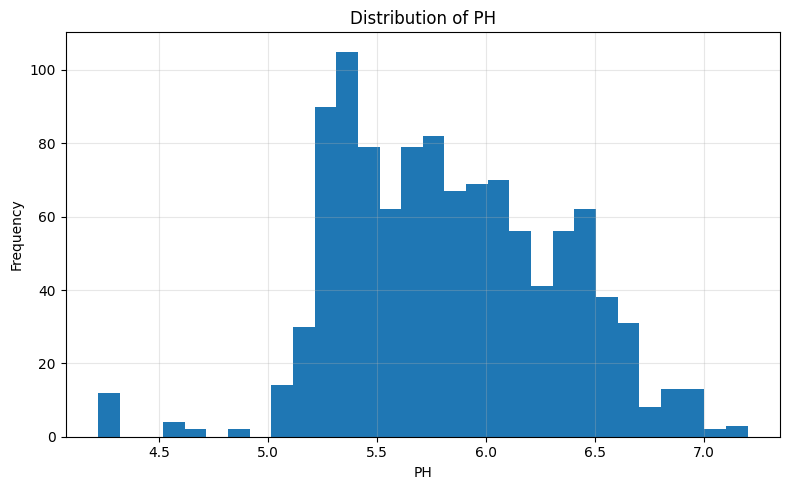

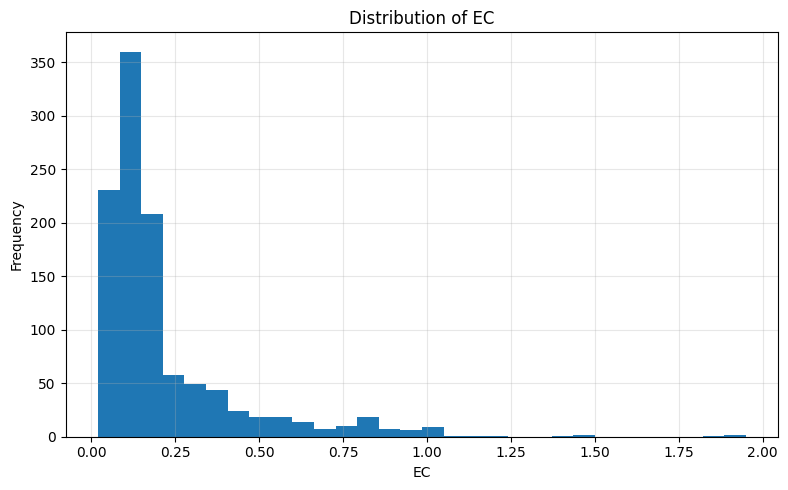

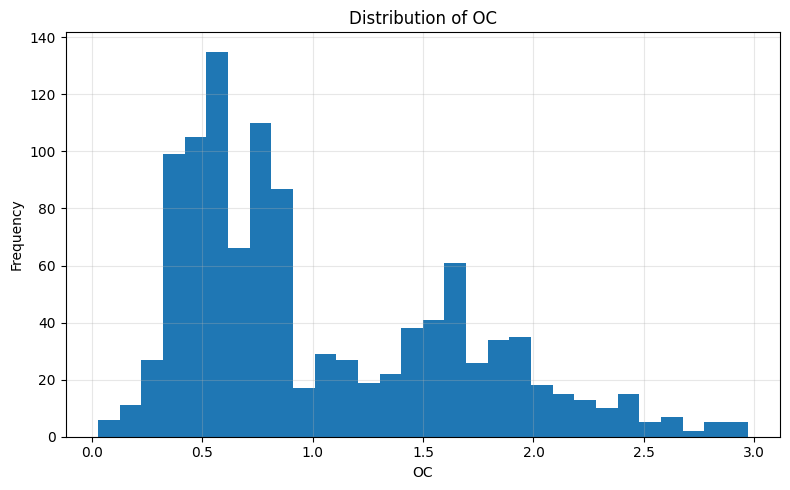

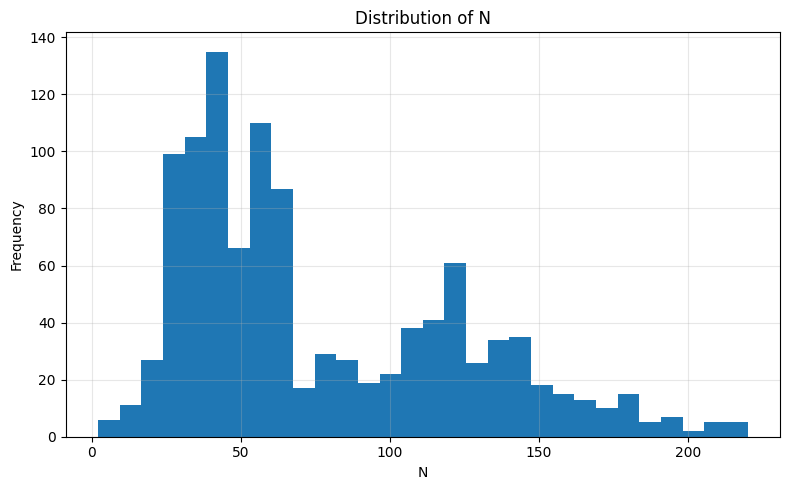

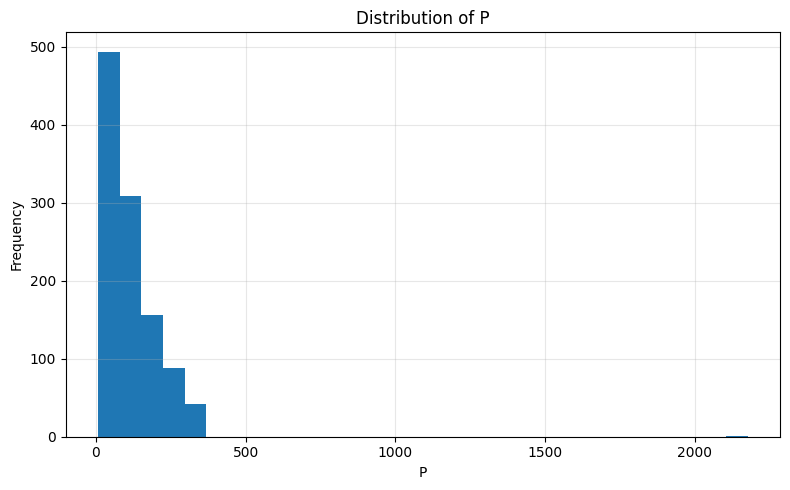

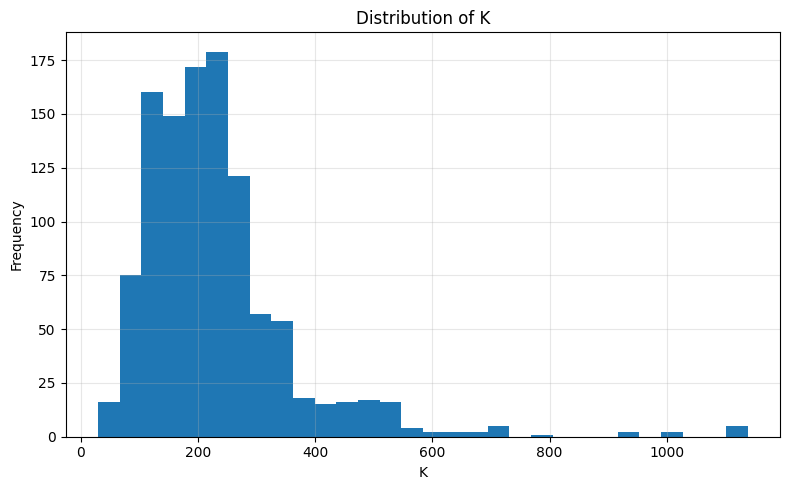

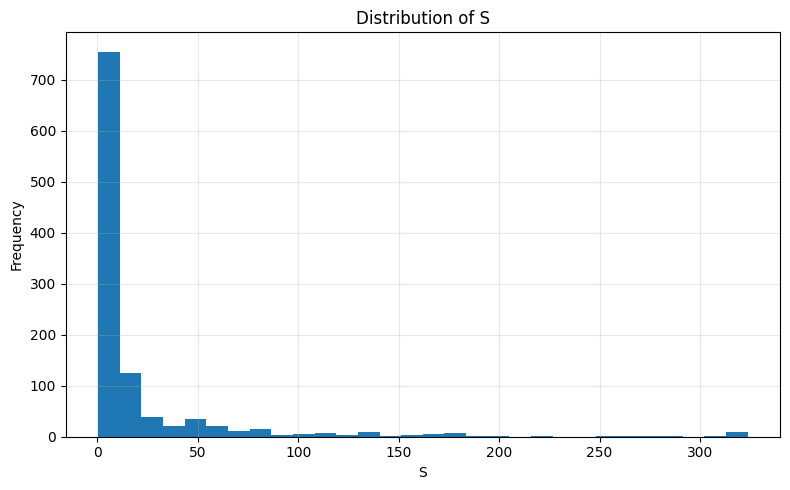

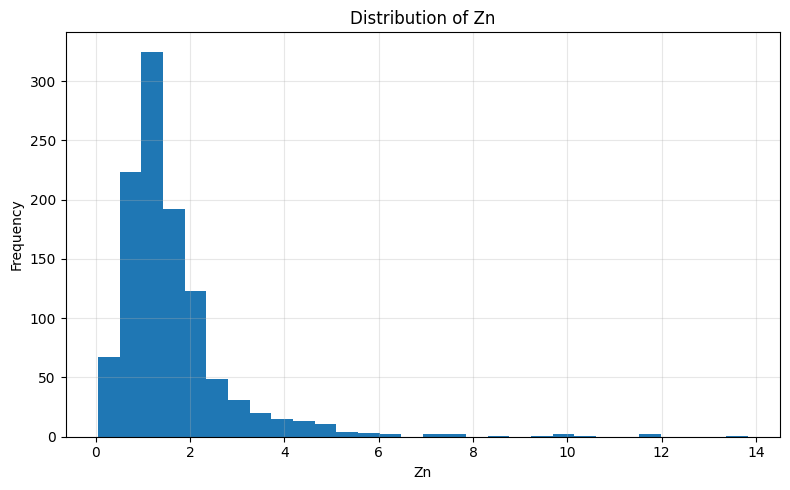

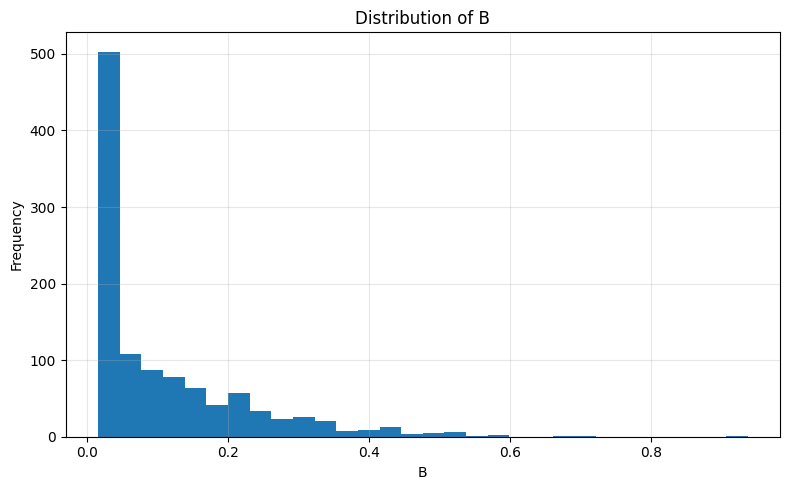

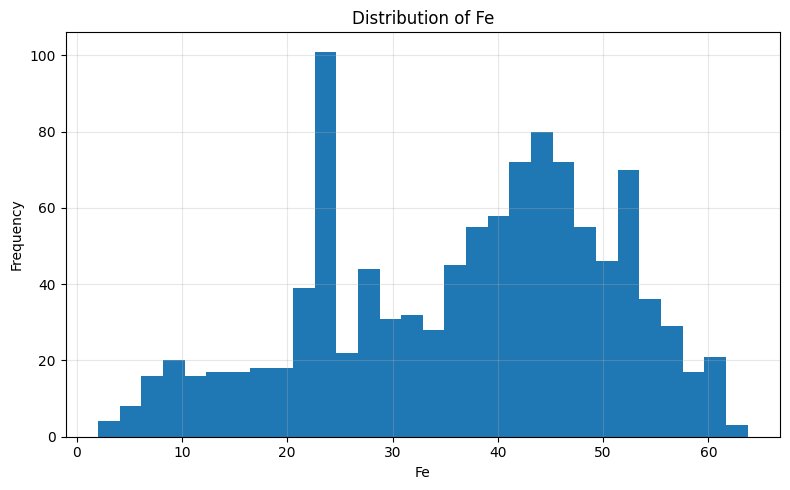

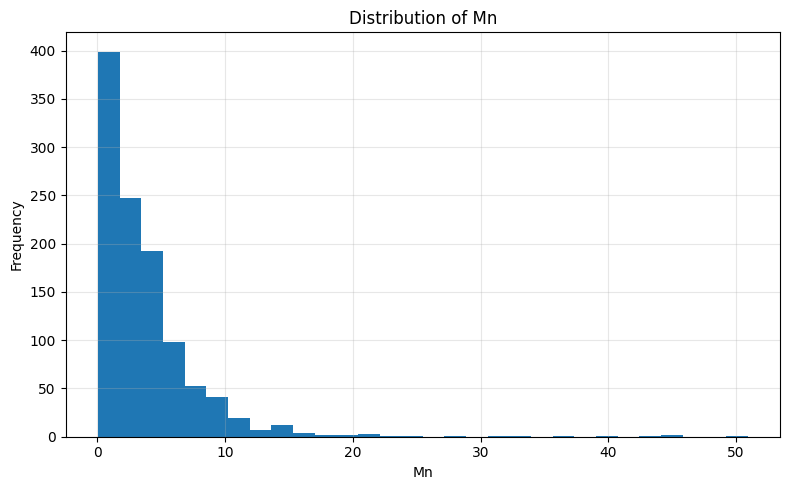

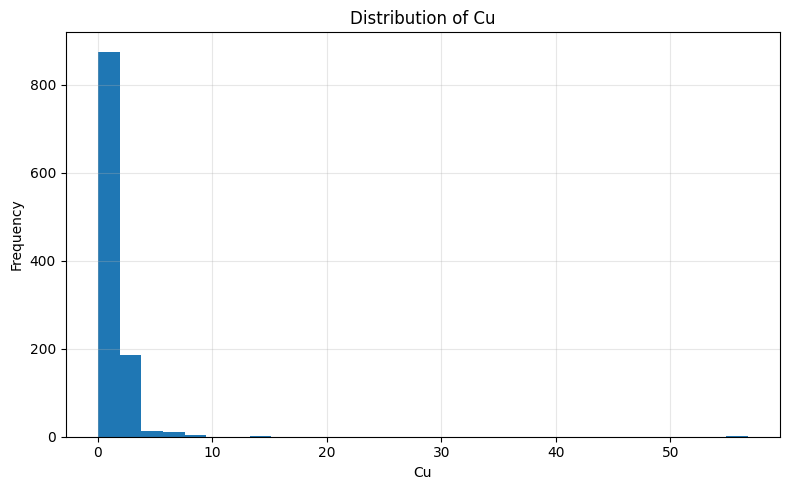

In [7]:
import matplotlib.pyplot as plt


for col in soil_cols:

    plt.figure(figsize=(8,5))

    plt.hist(df1[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers, lower, upper


for col in soil_cols:

    outliers, lower, upper = detect_outliers(df1, col)

    print(
        col,
        "Outliers:", len(outliers),
        "Lower:", lower,
        "Upper:", upper
    )

PH Outliers: 6 Lower: 4.27875 Upper: 7.34875
EC Outliers: 124 Lower: -0.12000000000000002 Upper: 0.44000000000000006
OC Outliers: 0 Lower: -0.98066008 Upper: 3.0672692880000003
N Outliers: 0 Lower: -72.666911925 Upper: 227.28465419499997
P Outliers: 10 Lower: -131.50349999999997 Upper: 334.6893
K Outliers: 63 Lower: -42.87529999999998 Upper: 457.5415
S Outliers: 169 Lower: -15.5925 Upper: 34.6275
Zn Outliers: 75 Lower: -0.5342500000000001 Upper: 3.42375
B Outliers: 42 Lower: -0.17202199999999998 Upper: 0.36777
Fe Outliers: 0 Lower: -9.999999999999993 Upper: 81.95999999999998
Mn Outliers: 57 Lower: -4.082750000000002 Upper: 10.399250000000002
Cu Outliers: 54 Lower: -0.6552624999999999 Upper: 3.1294375


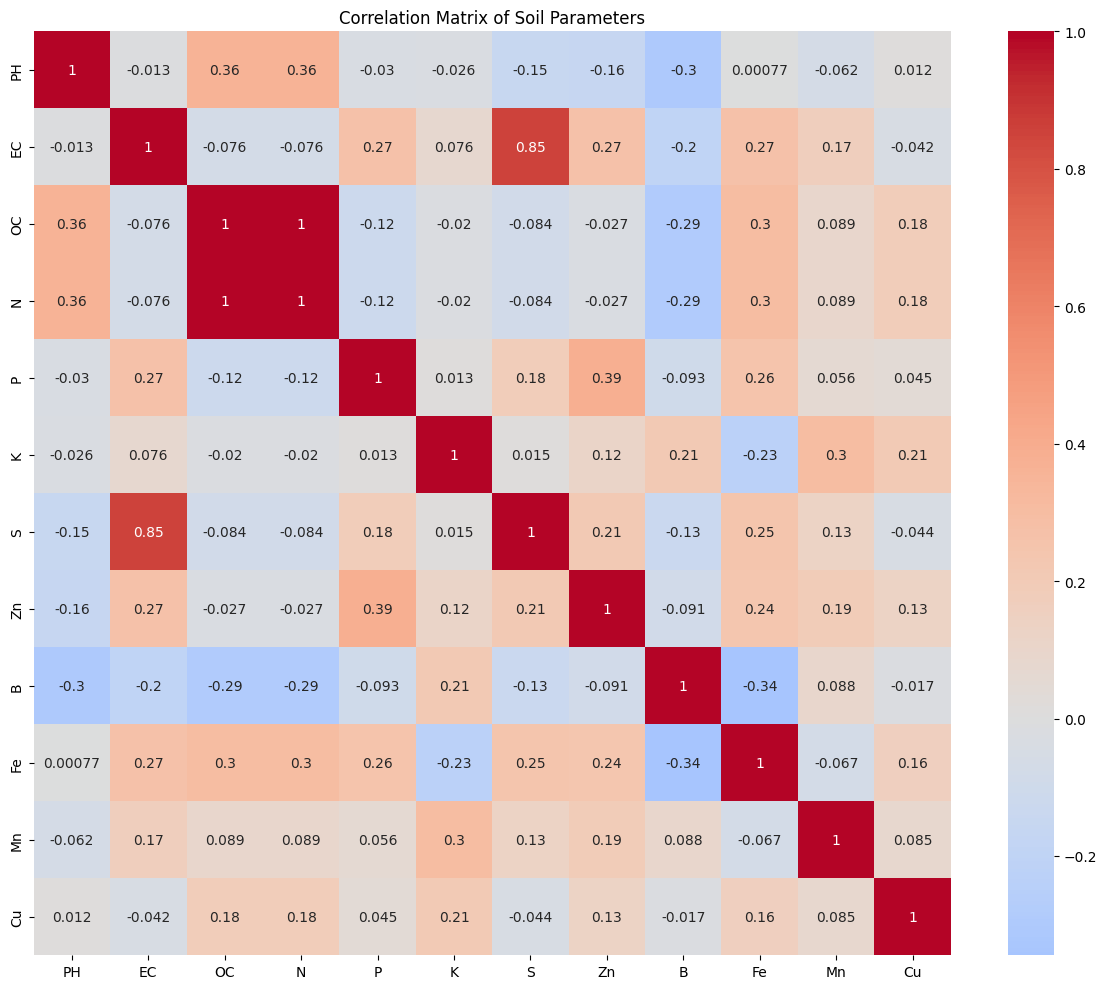

In [9]:
import seaborn as sns

corr = df1[soil_cols].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Soil Parameters")

plt.tight_layout()
plt.show()

2019-20_Soil_Test_Results_Samples-2500_Samples.csv

In [10]:
df2 = pd.read_csv("/content/2019-20_Soil_Test_Results_Samples-2500_Samples.csv")

print("Shape:", df2.shape)

print("\nColumns:")
print(df2.columns)

print("\nData Types:")
print(df2.dtypes)

print("\nFirst 5 rows:")
print(df2.head())

Shape: (2500, 17)

Columns:
Index(['Reg Sl. No', 'Longitude', 'Latitude', 'Taluk', 'Place', 'PH', 'EC',
       'OC', 'N', 'P', 'K', 'S', 'Zn', 'B', 'Fe', 'Mn', 'Cu'],
      dtype='object')

Data Types:
Reg Sl. No      int64
Longitude     float64
Latitude       object
Taluk          object
Place          object
PH            float64
EC            float64
OC            float64
N             float64
P             float64
K             float64
S             float64
Zn            float64
B             float64
Fe            float64
Mn            float64
Cu            float64
dtype: object

First 5 rows:
   Reg Sl. No  Longitude   Latitude  Taluk   Place    PH    EC        OC  \
0           1  74.847610  13.224204  Udupi  Shirva  6.07  0.18  0.823529   
1           2  74.846131  13.228091  Udupi  Shirva  6.19  0.11  0.455882   
2           3  74.847078   13.22418  Udupi  Shirva  6.08  0.15  0.897059   
3           4  74.826477  13.240884  Udupi  Shirva  6.11  0.15  0.470588   
4           5  

In [11]:
missing = df2.isnull().sum()
print(missing)

missing_percent = df2.isnull().mean() * 100
print(missing_percent)

Reg Sl. No      0
Longitude     114
Latitude      114
Taluk           0
Place           0
PH              0
EC              0
OC              0
N               0
P               0
K               0
S               0
Zn              0
B               0
Fe              0
Mn              0
Cu              0
dtype: int64
Reg Sl. No    0.00
Longitude     4.56
Latitude      4.56
Taluk         0.00
Place         0.00
PH            0.00
EC            0.00
OC            0.00
N             0.00
P             0.00
K             0.00
S             0.00
Zn            0.00
B             0.00
Fe            0.00
Mn            0.00
Cu            0.00
dtype: float64


In [12]:
soil_cols = [
    "PH", "EC", "OC", "N", "P", "K",
    "S", "Zn", "B", "Fe", "Mn", "Cu"
]

stats = df2[soil_cols].describe().T

print(stats)

     count        mean         std        min         25%         50%  \
PH  2500.0    5.474776    0.516453   4.330000    5.090000    5.290000   
EC  2500.0    0.166194    0.298546   0.010000    0.050000    0.080000   
OC  2500.0    0.580648    0.377136   0.014388    0.298507    0.559142   
N   2500.0   43.025985   27.945804   1.066187   22.119403   41.432454   
P   2500.0   70.026083   64.753439   0.687600   19.940400   51.913800   
K   2500.0  304.049401  233.146934  37.229400  172.507400  229.525400   
S   2500.0   34.762785   86.526778   0.324000    2.849671    6.839210   
Zn  2500.0    1.421652    1.571650   0.000000    0.506000    0.902000   
B   2500.0    0.174314    0.189295   0.018372    0.055116    0.128604   
Fe  2500.0   27.544556   22.941483   0.288000    6.225000   22.790000   
Mn  2500.0    8.261688    9.525908   0.046000    2.257000    4.424000   
Cu  2500.0    3.252519   11.402563   0.022000    0.372000    0.934000   

           75%          max  
PH    5.730000     7

In [13]:
summary = pd.DataFrame({
    "Mean": df1[soil_cols].mean(),
    "Median": df1[soil_cols].median(),
    "Std": df1[soil_cols].std(),
    "Min": df1[soil_cols].min(),
    "Max": df1[soil_cols].max()
})

print(summary)

          Mean      Median         Std        Min          Max
PH    5.833055    5.770000    0.501940   4.220000     7.200000
EC    0.219587    0.140000    0.230187   0.020000     1.950000
OC    1.033133    0.805970    0.629594   0.029484     2.969072
N    76.555115   59.722388   46.652692   2.184767   220.008247
P   111.728692   87.669000  101.685538   7.563600  2176.254000
K   230.769429  208.730600  134.656375  29.962400  1137.730464
S    23.042642    6.804000   48.394549   0.324000   323.676000
Zn    1.639939    1.309000    1.293013   0.050000    13.822000
B     0.110360    0.060800    0.116797   0.015200     0.936972
Fe   36.874559   39.790000   13.830038   2.036000    63.720000
Mn    3.945445    2.670000    4.695196   0.052000    50.900000
Cu    1.457004    1.230300    1.997573   0.020000    56.740000


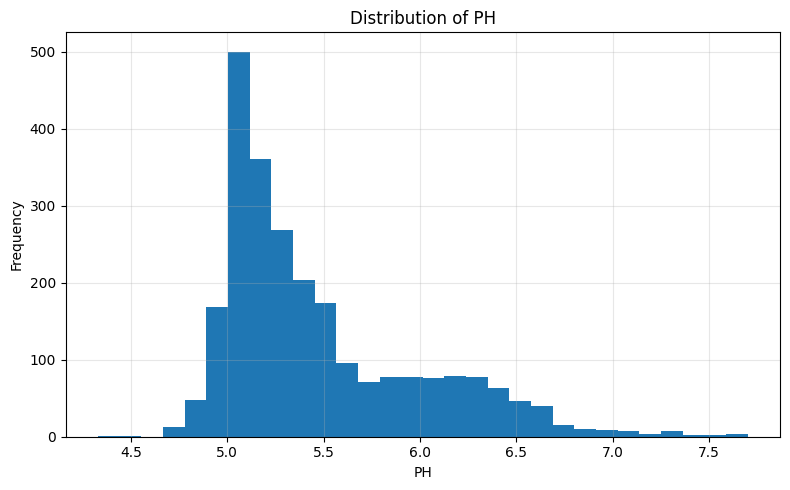

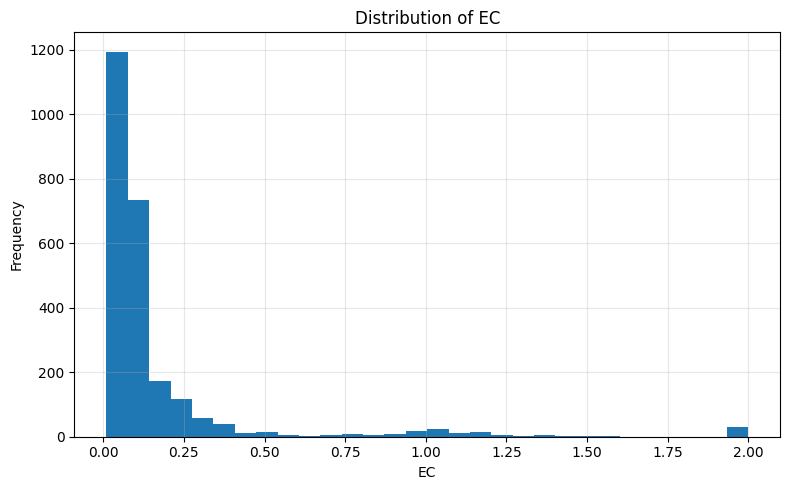

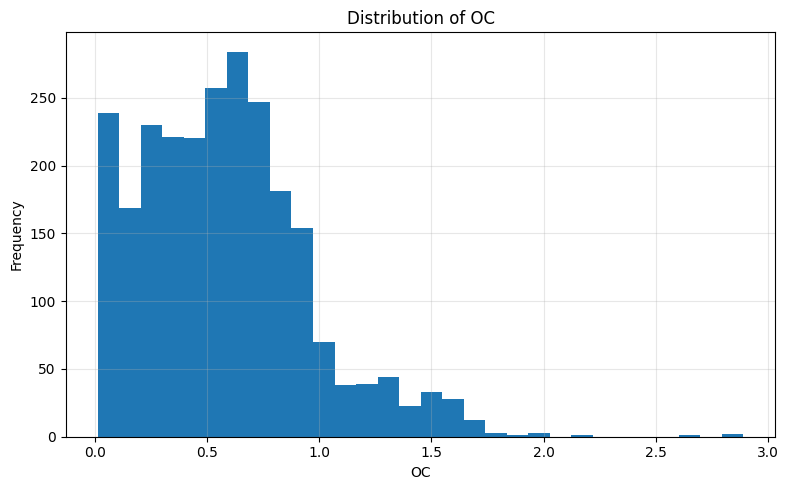

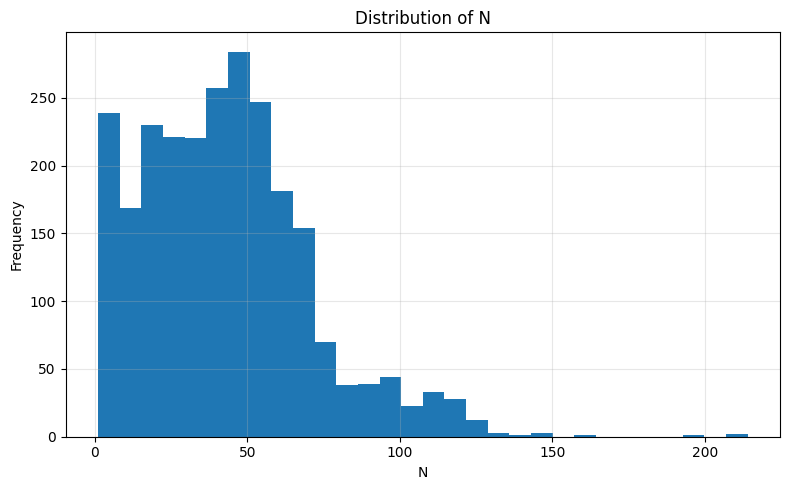

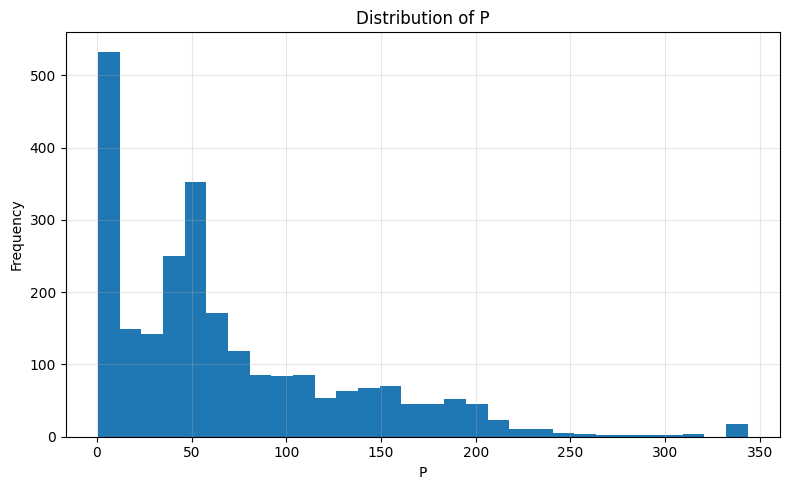

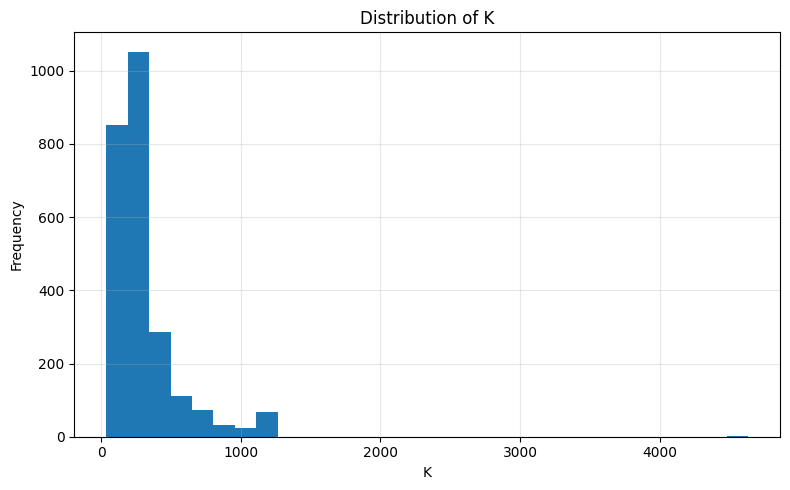

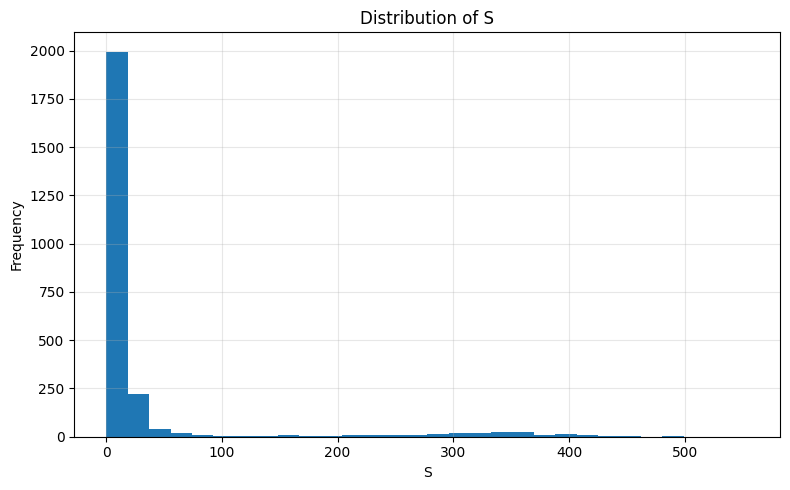

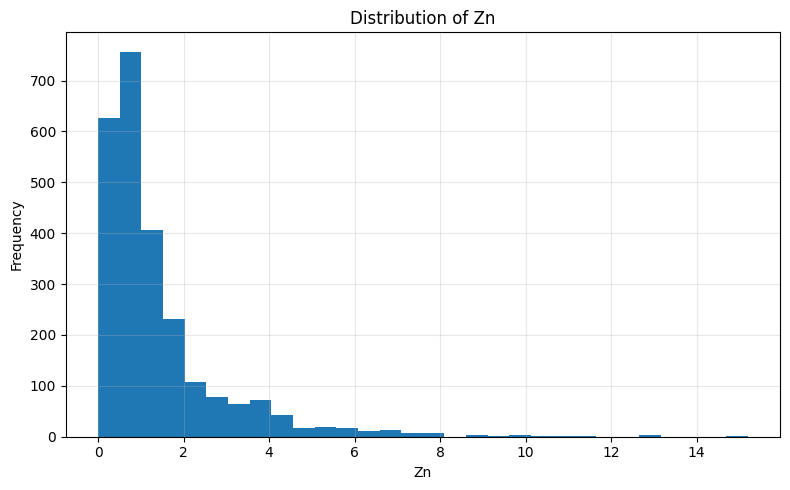

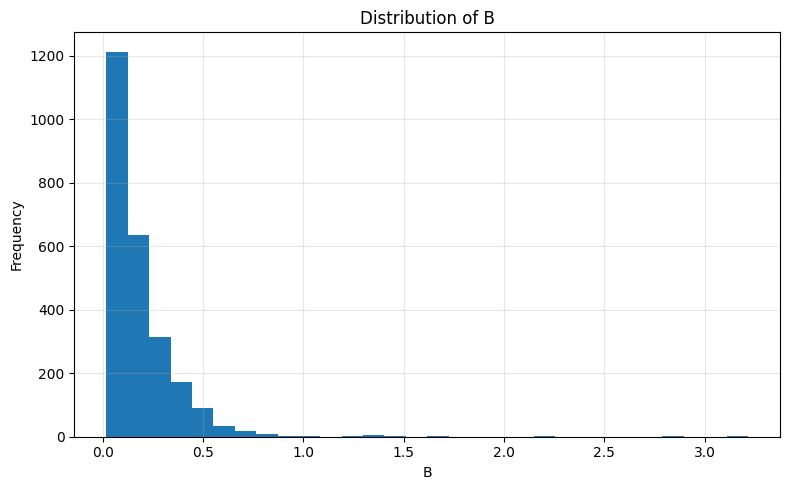

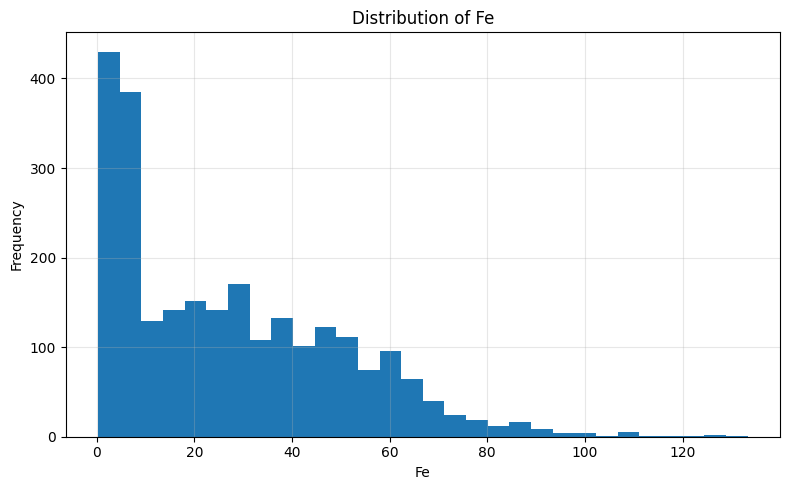

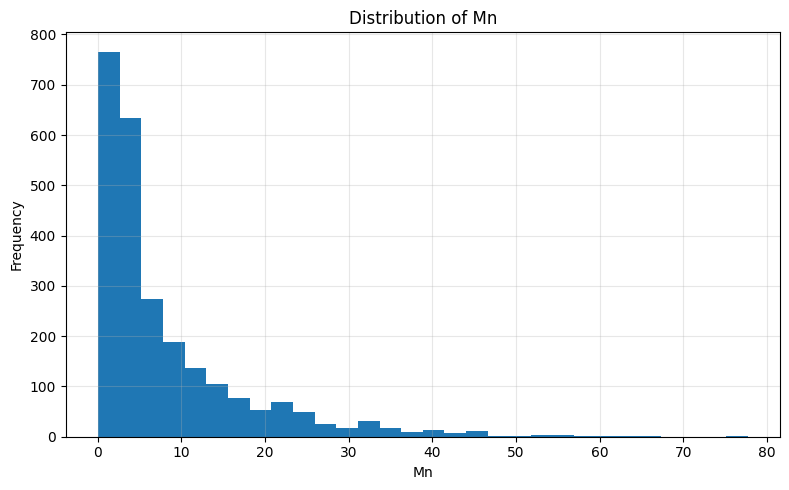

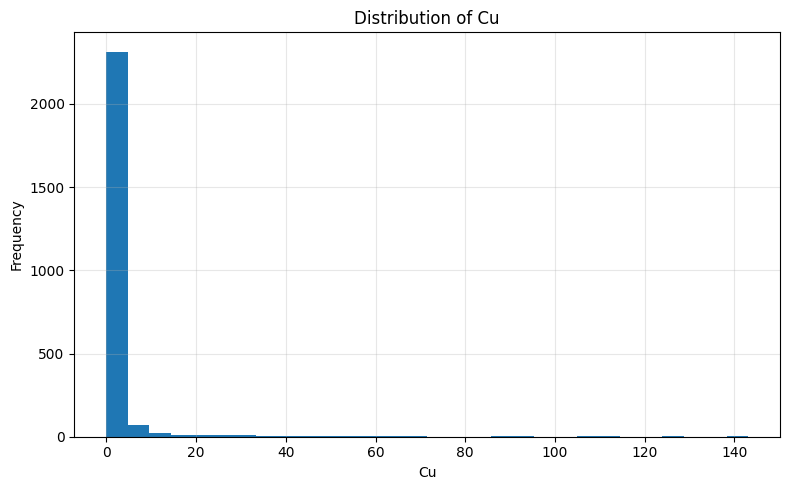

In [14]:
import matplotlib.pyplot as plt


for col in soil_cols:

    plt.figure(figsize=(8,5))

    plt.hist(df2[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers, lower, upper


for col in soil_cols:

    outliers, lower, upper = detect_outliers(df2, col)

    print(
        col,
        "Outliers:", len(outliers),
        "Lower:", lower,
        "Upper:", upper
    )

PH Outliers: 56 Lower: 4.129999999999999 Upper: 6.690000000000001
EC Outliers: 307 Lower: -0.06999999999999999 Upper: 0.25
OC Outliers: 60 Lower: -0.4300047655 Upper: 1.5126945104999998
N Outliers: 60 Lower: -31.863353171250008 Upper: 112.09066325875001
P Outliers: 56 Lower: -103.8276 Upper: 226.22039999999998
K Outliers: 234 Lower: -71.16070000000005 Upper: 578.6209000000001
S Outliers: 348 Lower: -14.248354999999997 Upper: 31.346380999999997
Zn Outliers: 239 Lower: -1.2309999999999999 Upper: 3.401
B Outliers: 96 Lower: -0.220464 Upper: 0.514416
Fe Outliers: 16 Lower: -50.3175 Upper: 100.4625
Mn Outliers: 203 Lower: -10.301 Upper: 23.186999999999998
Cu Outliers: 180 Lower: -2.4210000000000003 Upper: 5.027


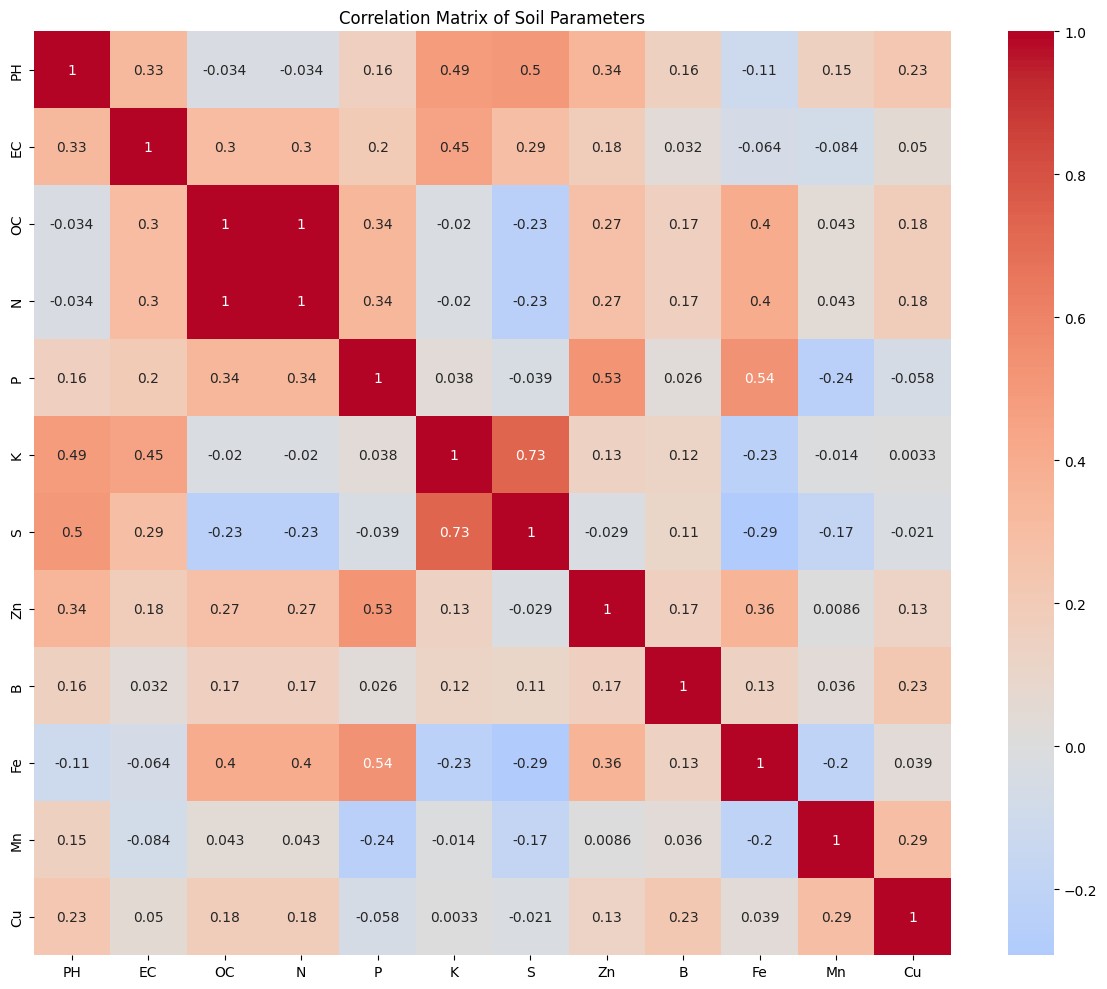

In [16]:
import seaborn as sns

corr = df2[soil_cols].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Soil Parameters")

plt.tight_layout()
plt.show()

2020-21_Soil_Test_Results_Samples.csv

In [17]:
df3 = pd.read_csv("/content/2020-21_Soil_Test_Results_Samples.csv")

print("Shape:", df3.shape)

print("\nColumns:")
print(df3.columns)

print("\nData Types:")
print(df3.dtypes)

print("\nFirst 5 rows:")
print(df3.head())

Shape: (4562, 30)

Columns:
Index(['Reg Sl. No', 'Longitude', 'Latitude', 'Hobli', 'Place', 'PH', 'EC',
       'OC', 'N', 'P', 'K', 'S', 'Zn', 'B', 'Fe', 'Mn', 'Cu', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25',
       'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29'],
      dtype='object')

Data Types:
Reg Sl. No       int64
Longitude       object
Latitude        object
Hobli           object
Place           object
PH             float64
EC             float64
OC             float64
N               object
P              float64
K              float64
S              float64
Zn             float64
B              float64
Fe             float64
Mn             float64
Cu             float64
Unnamed: 17    float64
Unnamed: 18    float64
Unnamed: 19    float64
Unnamed: 20    float64
Unnamed: 21    float64
Unnamed: 22    float64
Unnamed: 23    float64
Unnamed: 24    float64
Unnamed

In [26]:
df3 = df3.loc[:, ~df3.columns.str.contains('^Unnamed')]
df3 = df3.drop(columns=["Reg Sl. No","Longitude","Latitude", "Hobli","Place"])

In [30]:
missing = df3.isnull().sum()
print(missing)

missing_percent = df3.isnull().mean() * 100
print(missing_percent)

df3 = df3.dropna()

PH    0
EC    1
OC    0
N     0
P     0
K     0
S     0
Zn    0
B     0
Fe    0
Mn    0
Cu    0
dtype: int64
PH    0.00000
EC    0.02192
OC    0.00000
N     0.00000
P     0.00000
K     0.00000
S     0.00000
Zn    0.00000
B     0.00000
Fe    0.00000
Mn    0.00000
Cu    0.00000
dtype: float64


In [39]:
for col in df3.columns:
    if df3[col].dtype == 'object':
        df3[col] = pd.to_numeric(df3[col], errors='coerce')

# 2. Replace infinity values and drop any rows containing NaNs or conversion errors
df3 = df3.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Convert all remaining numbers to integers
df3 = df3.astype(int)

In [40]:
summary = pd.DataFrame({
    "Mean": df3[soil_cols].mean(),
    "Median": df3[soil_cols].median(),
    "Std": df3[soil_cols].std(),
    "Min": df3[soil_cols].min(),
    "Max": df3[soil_cols].max()
})

print(summary)

          Mean  Median         Std  Min   Max
PH    4.958772     5.0    7.856526    3   534
EC    0.006140     0.0    0.078128    0     1
OC    0.678947     1.0    0.704073    0     5
N    95.196491    85.0   56.997547    1   451
P    57.484649    45.5   50.338196    0   515
K   213.234649   181.0  145.331724    6  1934
S    13.237281    10.0   22.349520    0   512
Zn    1.356140     1.0    1.738789    0    20
B     0.038596     0.0    0.270347    0     6
Fe   38.858114    38.0   20.815672    0   114
Mn    7.073026     4.0    8.605470    0    81
Cu    1.819079     1.0    5.295185    0   132


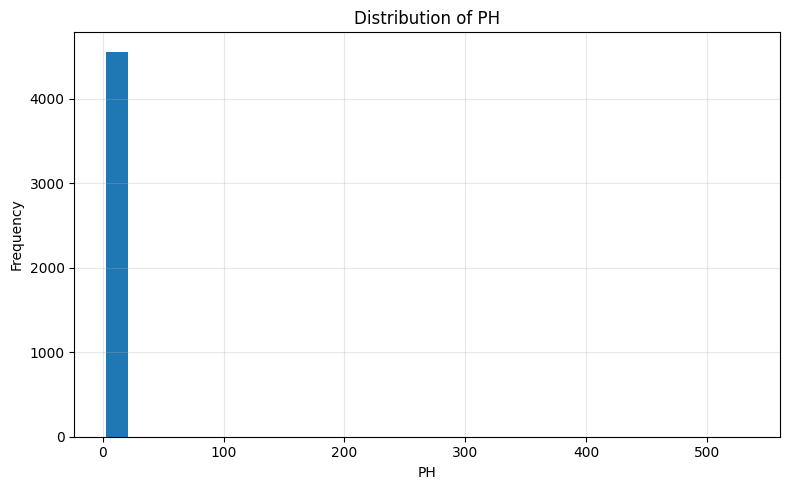

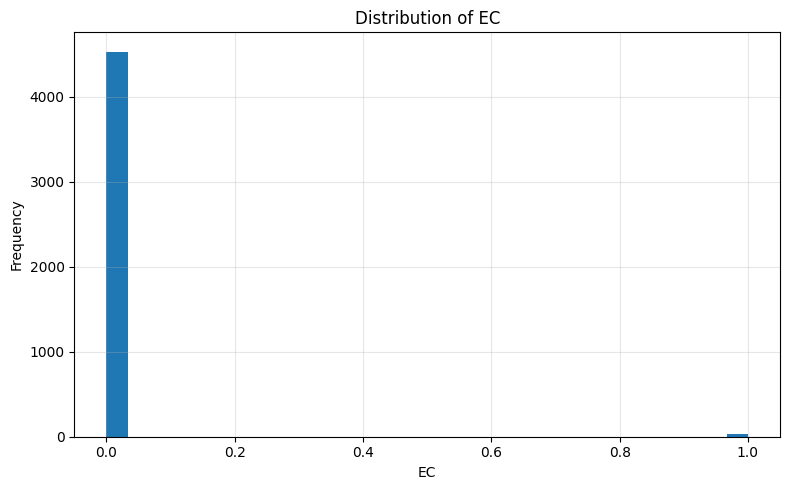

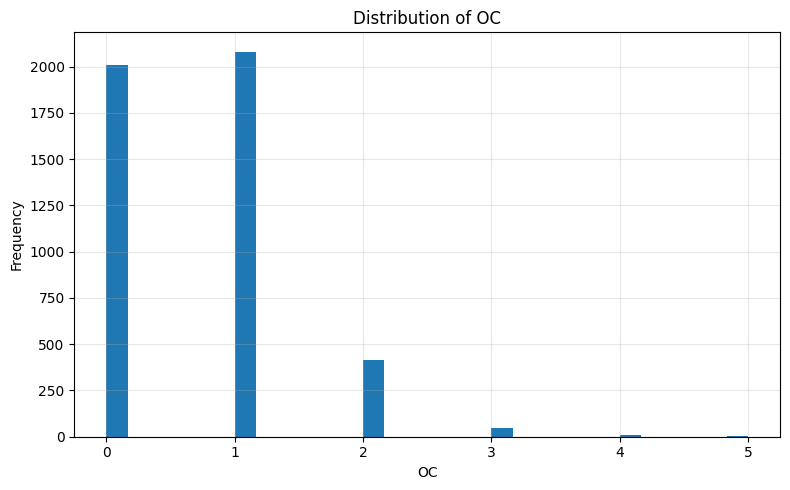

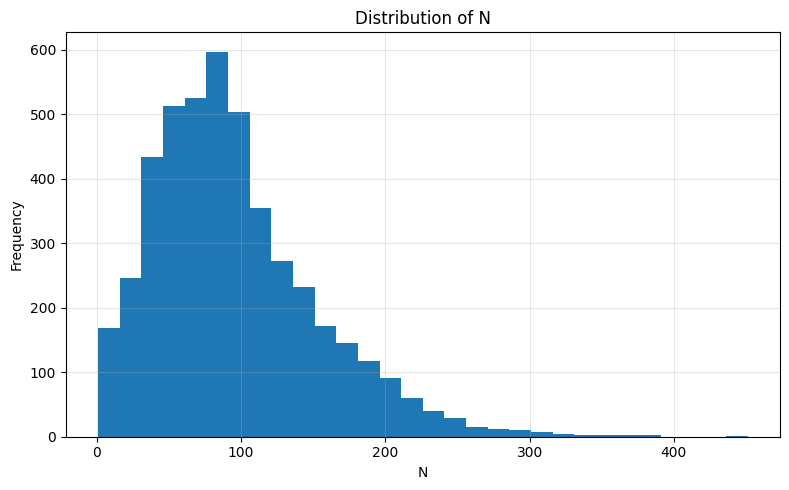

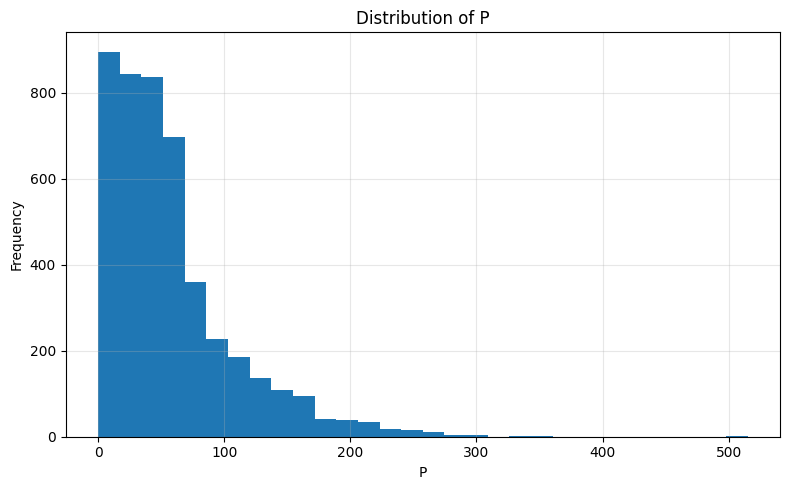

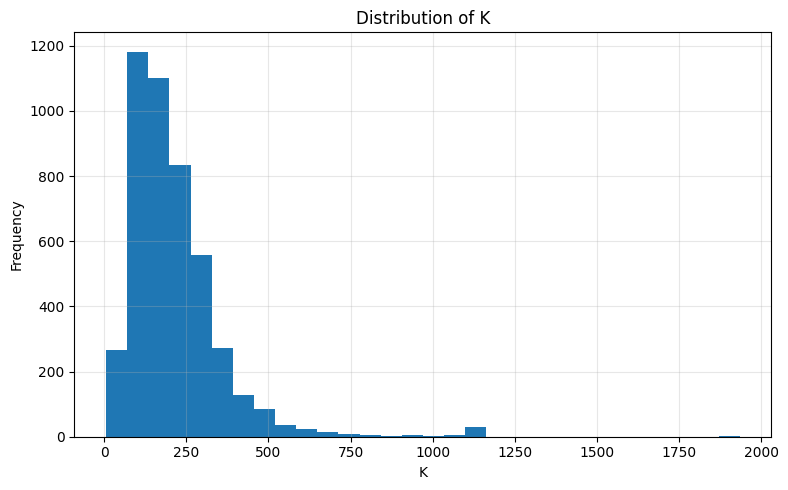

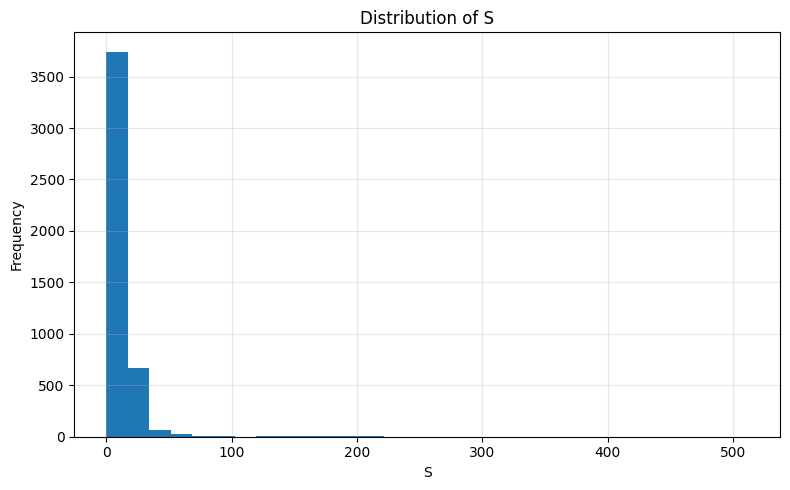

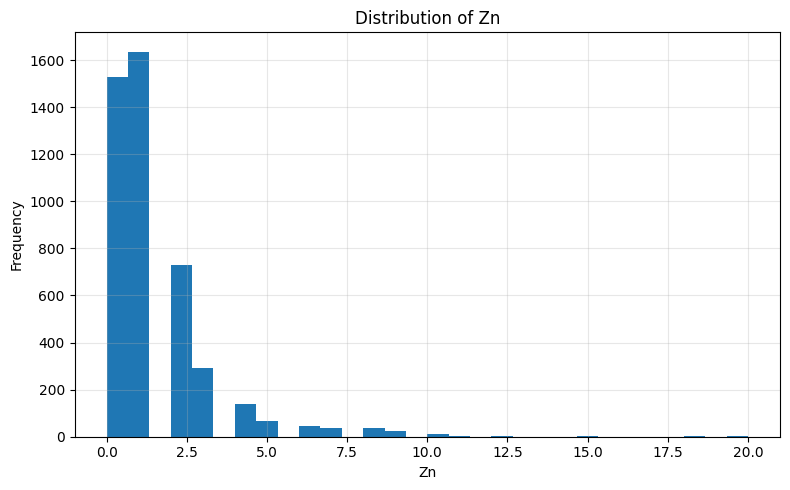

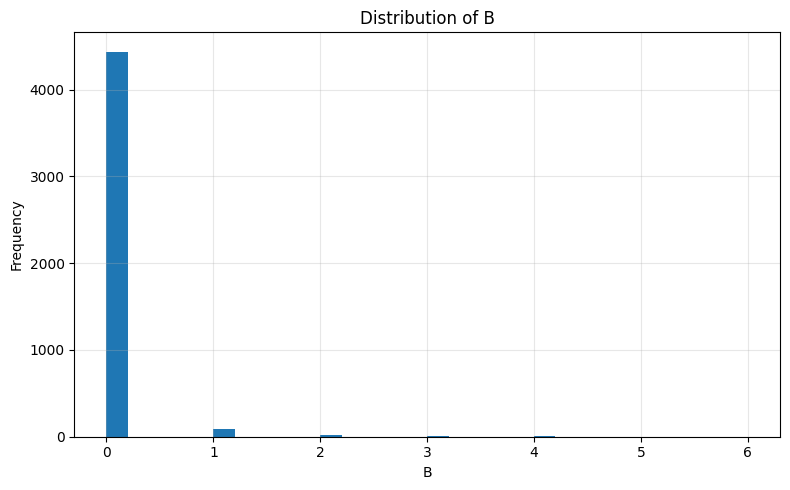

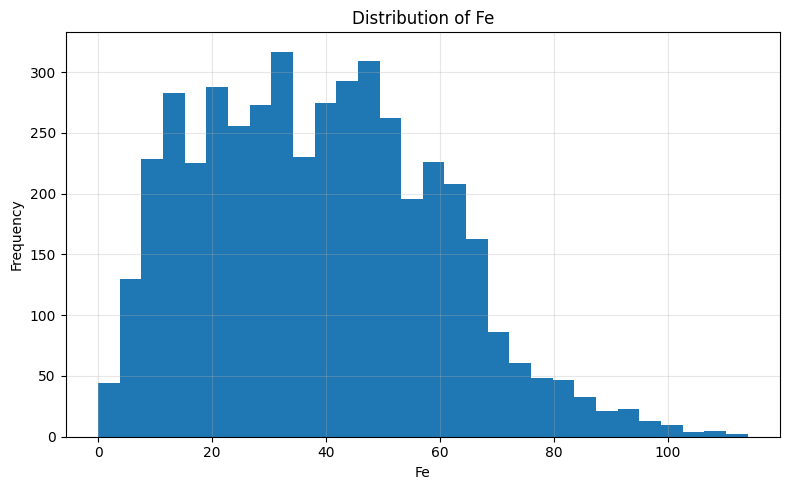

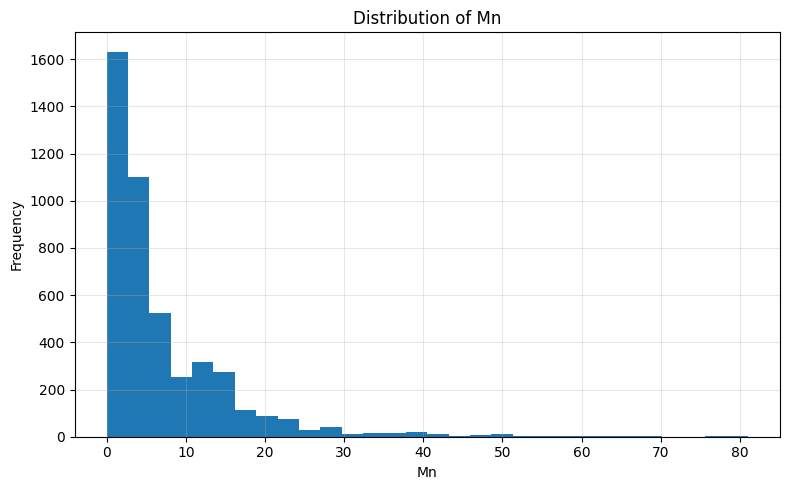

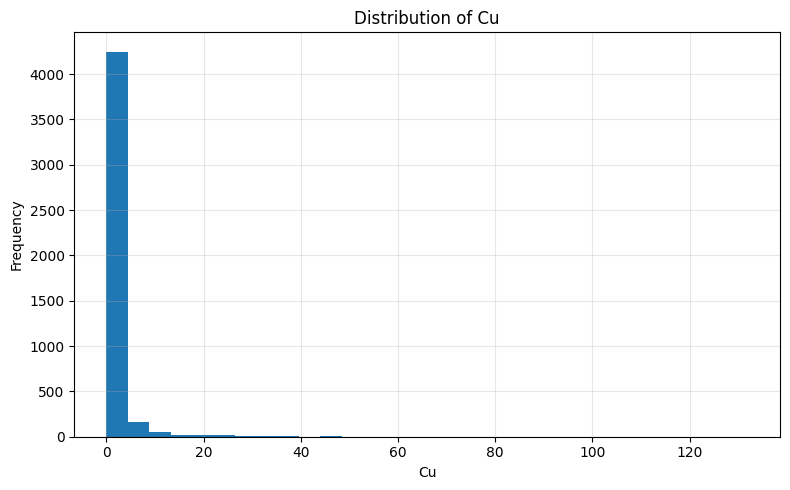

In [41]:
import matplotlib.pyplot as plt


for col in soil_cols:

    plt.figure(figsize=(8,5))

    plt.hist(df3[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [42]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers, lower, upper


for col in soil_cols:

    outliers, lower, upper = detect_outliers(df3, col)

    print(
        col,
        "Outliers:", len(outliers),
        "Lower:", lower,
        "Upper:", upper
    )

PH Outliers: 1512 Lower: 5.0 Upper: 5.0
EC Outliers: 28 Lower: 0.0 Upper: 0.0
OC Outliers: 59 Lower: -1.5 Upper: 2.5
N Outliers: 109 Lower: -50.0 Upper: 230.0
P Outliers: 296 Lower: -55.5 Upper: 150.5
K Outliers: 168 Lower: -94.0 Upper: 482.0
S Outliers: 231 Lower: -7.5 Upper: 28.5
Zn Outliers: 168 Lower: -3.0 Upper: 5.0
B Outliers: 122 Lower: 0.0 Upper: 0.0
Fe Outliers: 11 Lower: -26.0 Upper: 102.0
Mn Outliers: 234 Lower: -10.0 Upper: 22.0
Cu Outliers: 244 Lower: -3.0 Upper: 5.0


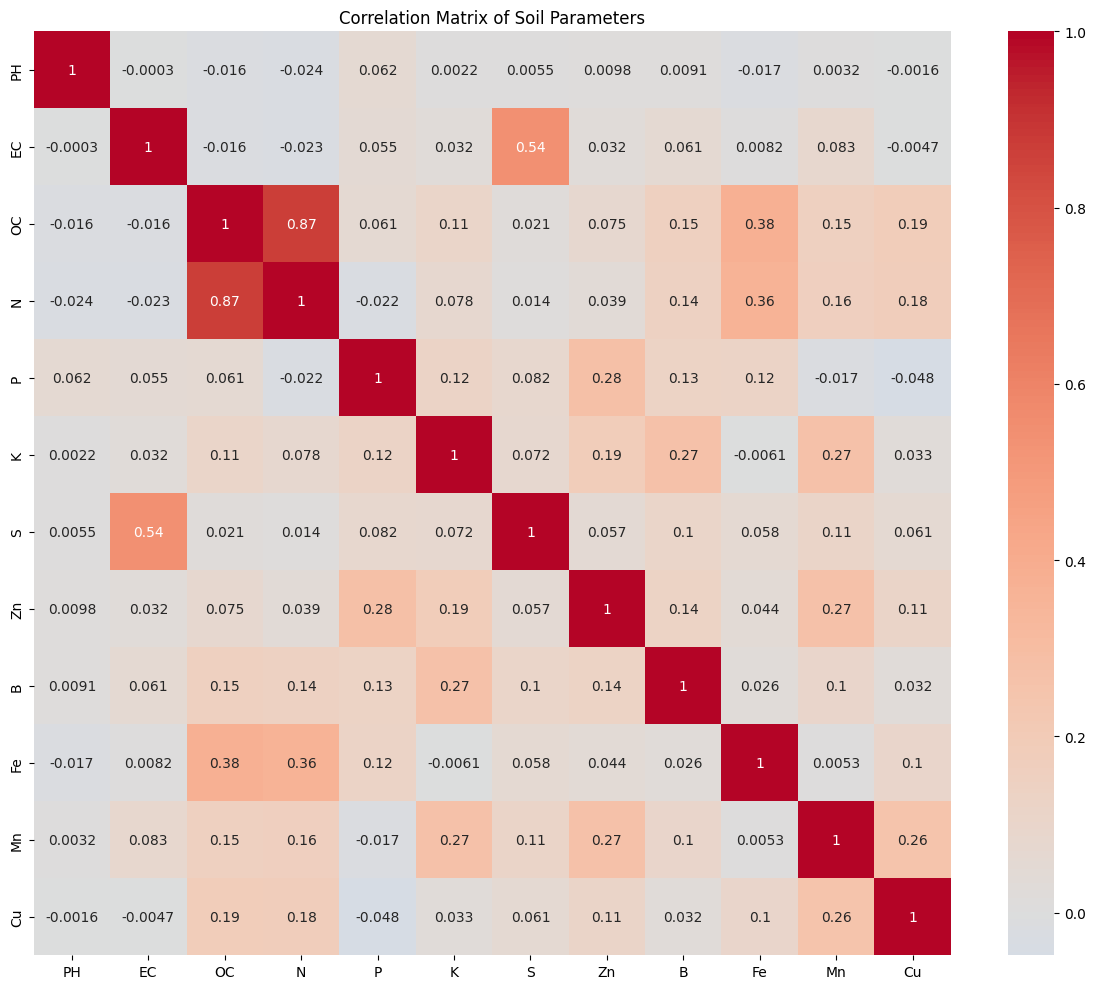

In [44]:
import seaborn as sns

corr = df3[soil_cols].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Soil Parameters")

plt.tight_layout()
plt.show()

2022-23_Soil_Test_Results_Samples.csv

In [57]:
df4 = pd.read_csv("/content/2022-23_Soil_Test_Results_Samples.csv")

print("Shape:", df4.shape)

print("\nColumns:")
print(df4.columns)

print("\nData Types:")
print(df4.dtypes)

print("\nFirst 5 rows:")
print(df4.head())

Shape: (5208, 14)

Columns:
Index(['Register No ', 'Place', 'pH', 'EC       ds/m', 'OC            %',
       'N          kg/hectre', 'P          kg/hectre', 'K        kg/hectre',
       'S         ppm', 'Zn                ppm    ', 'B          ppm',
       'Fe        ppm', 'Mn      ppm', 'Cu        ppm'],
      dtype='object')

Data Types:
Register No                    int64
Place                         object
pH                           float64
EC       ds/m                float64
OC            %              float64
N          kg/hectre         float64
P          kg/hectre         float64
K        kg/hectre           float64
S         ppm                float64
Zn                ppm        float64
B          ppm               float64
Fe        ppm                float64
Mn      ppm                  float64
Cu        ppm                float64
dtype: object

First 5 rows:
   Register No    Place    pH  EC       ds/m  OC            %  \
0             1  Uppoor  5.50           0.09  

In [58]:
import re
STD_MAP = {
    'ph': 'PH', 'ec': 'EC', 'oc': 'OC', 'n': 'N', 'p': 'P', 'k': 'K', 's': 'S',
    'zn': 'Zn', 'b': 'B', 'fe': 'Fe', 'mn': 'Mn', 'cu': 'Cu',
}

def standardize_column(col):
    """'EC       ds/m' -> 'EC' ; 'N          kg/hectre' -> 'N' ; 'PH' -> 'pH' """
    cleaned = re.sub(r"\s+", " ", str(col)).strip()   # collapse multiple spaces into one
    first_word = cleaned.split(" ")[0].lower()
    return STD_MAP.get(first_word, cleaned)

In [59]:
df4.columns = [standardize_column(c) for c in df4.columns]

In [60]:
df4.head()

,Register No,Place,PH,EC,OC,N,P,K,S,Zn,B,Fe,Mn,Cu
0,1,Uppoor,5.50,0.09,1.147541,112.243279,0.54124,133.616,9.688881,1.450,0.367440,28.32,3.832,0.562
1,2,Uppoor,5.45,0.16,2.557377,250.142164,2.70620,231.168,7.979079,1.380,0.238836,36.60,4.324,0.492
2,3,Uppoor,5.74,0.18,2.590164,253.349115,4.60054,271.600,9.118947,1.146,0.514416,27.02,8.440,0.492
3,4,Uppoor,5.64,0.26,2.000000,195.624000,0.54124,120.400,10.828750,0.714,0.367440,24.14,3.744,0.936
4,5,Uppoor,5.76,0.14,2.000000,195.624000,8.11860,258.384,9.688881,1.112,0.440928,30.94,8.034,0.656


In [61]:
df4 = df4.drop(columns=["Register No","Place"])
df4.head()

,PH,EC,OC,N,P,K,S,Zn,B,Fe,Mn,Cu
0,5.50,0.09,1.147541,112.243279,0.54124,133.616,9.688881,1.450,0.367440,28.32,3.832,0.562
1,5.45,0.16,2.557377,250.142164,2.70620,231.168,7.979079,1.380,0.238836,36.60,4.324,0.492
2,5.74,0.18,2.590164,253.349115,4.60054,271.600,9.118947,1.146,0.514416,27.02,8.440,0.492
3,5.64,0.26,2.000000,195.624000,0.54124,120.400,10.828750,0.714,0.367440,24.14,3.744,0.936
4,5.76,0.14,2.000000,195.624000,8.11860,258.384,9.688881,1.112,0.440928,30.94,8.034,0.656


In [62]:
missing = df4.isnull().sum()
print(missing)

missing_percent = df4.isnull().mean() * 100
print(missing_percent)

df4 = df4.dropna()

PH    32
EC    32
OC    32
N     32
P     32
K     32
S     32
Zn    32
B     32
Fe    32
Mn    32
Cu    32
dtype: int64
PH    0.614439
EC    0.614439
OC    0.614439
N     0.614439
P     0.614439
K     0.614439
S     0.614439
Zn    0.614439
B     0.614439
Fe    0.614439
Mn    0.614439
Cu    0.614439
dtype: float64


In [63]:
summary = pd.DataFrame({
    "Mean": df4[soil_cols].mean(),
    "Median": df4[soil_cols].median(),
    "Std": df4[soil_cols].std(),
    "Min": df4[soil_cols].min(),
    "Max": df4[soil_cols].max()
})

print(summary)

          Mean      Median         Std       Min          Max
PH    5.012720    4.960000    0.488159  3.400000     6.900000
EC    0.212630    0.100000    0.314920  0.010000     1.990000
OC    1.480720    1.428571    0.699116  0.051282     5.612903
N   143.470099  138.829936   68.071508  3.800000   549.009290
P    47.083920   24.085180   59.856402  0.270620   985.868660
K   301.302192  241.416000  213.003878  4.908727  1118.880000
S    20.588617    7.979079   51.642746  0.324000   578.593470
Zn    1.594917    1.132000    1.524376  0.012600    14.180000
B     0.289200    0.220000    0.289799  0.015200     3.913236
Fe   29.546914   29.380000   15.912202  0.682000   118.140000
Mn    4.986194    3.180000    5.080793  0.020000    66.880000
Cu    1.468582    0.853000    2.434195  0.000000    95.160000


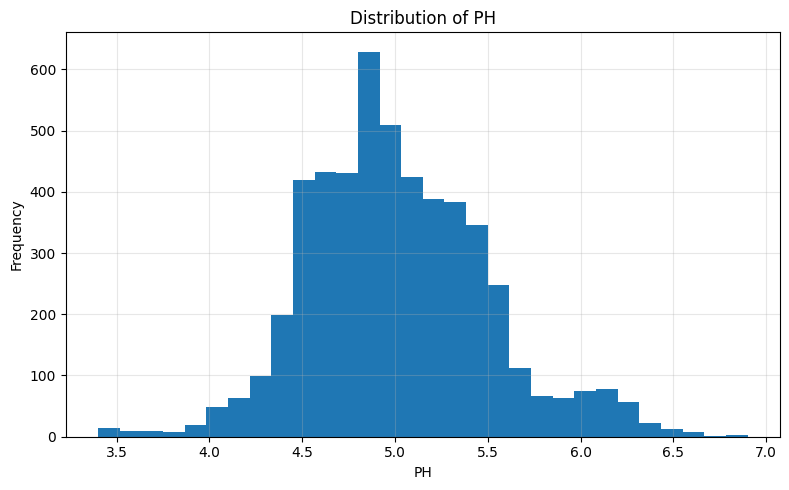

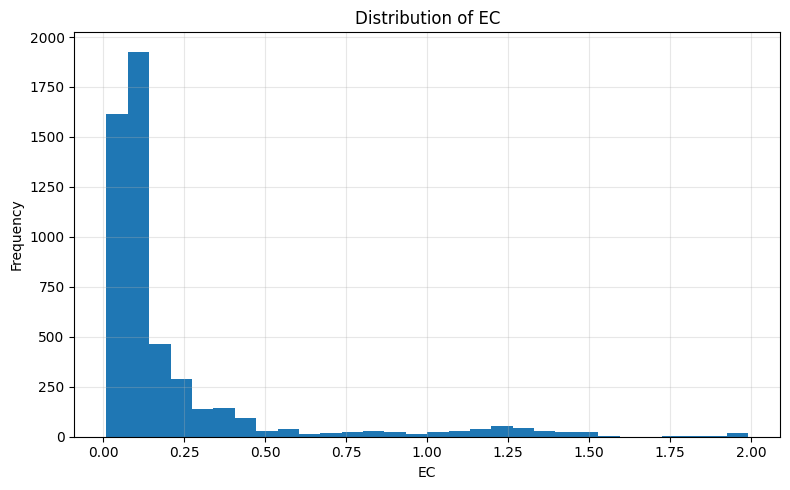

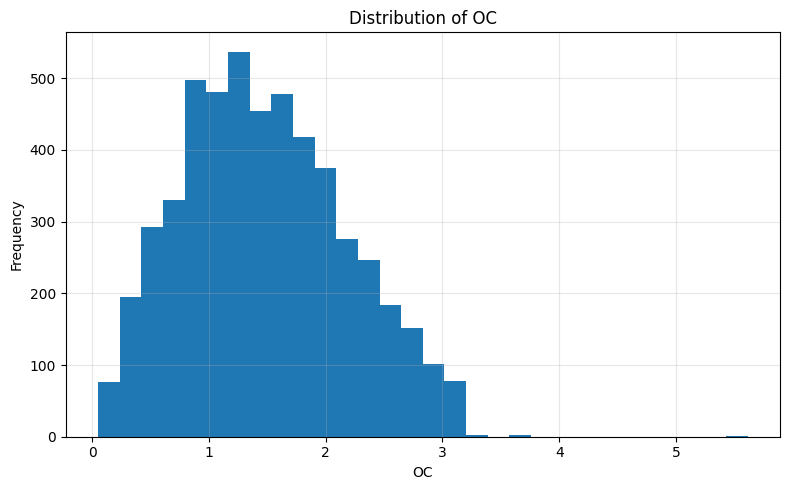

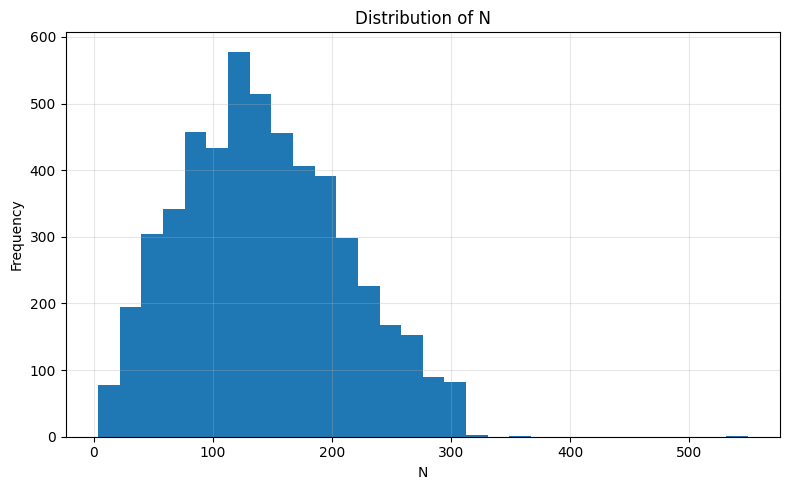

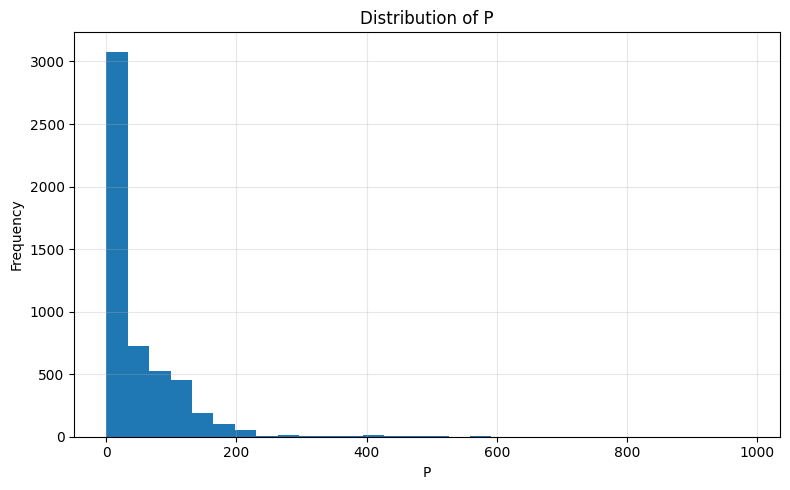

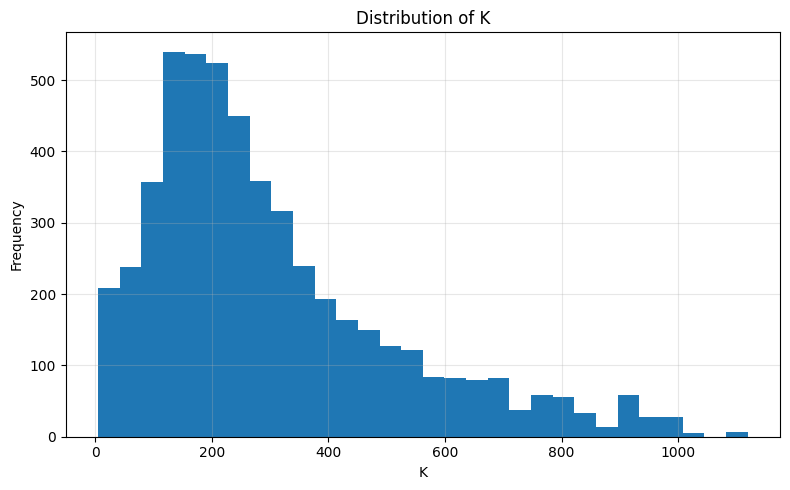

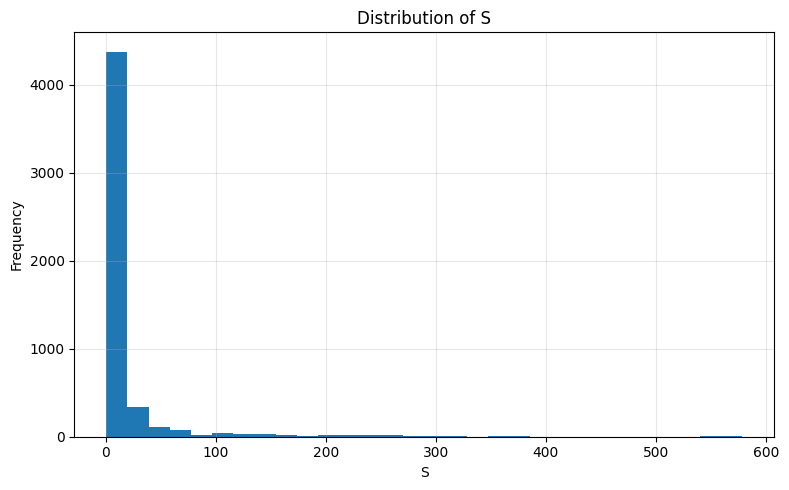

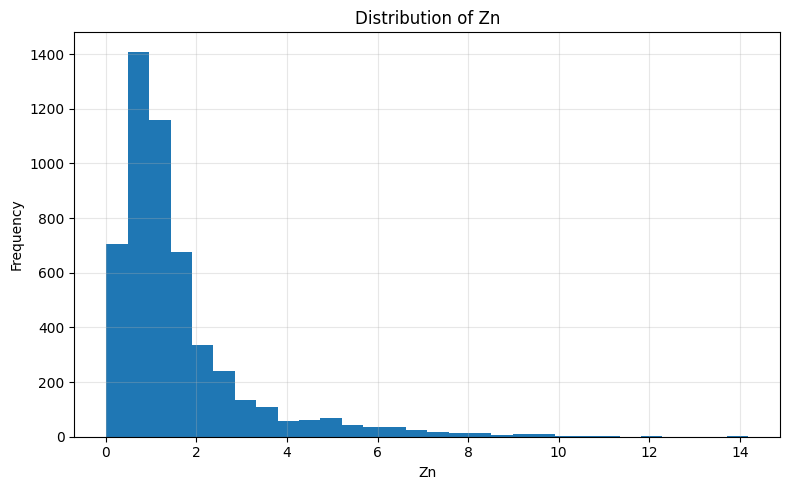

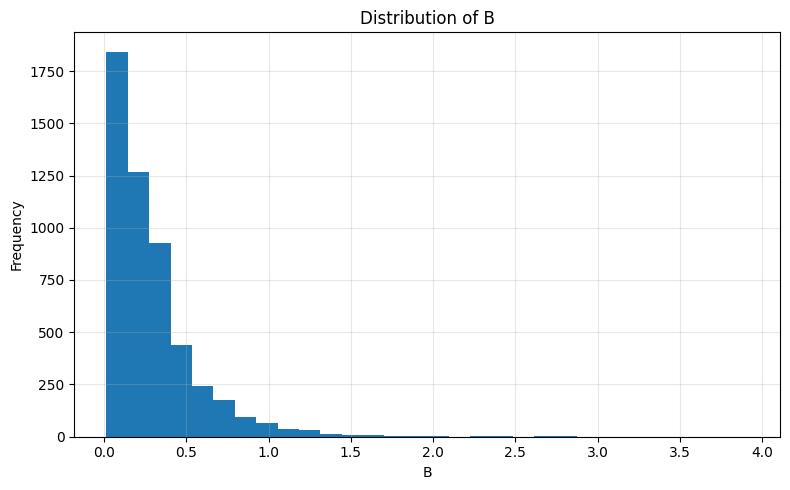

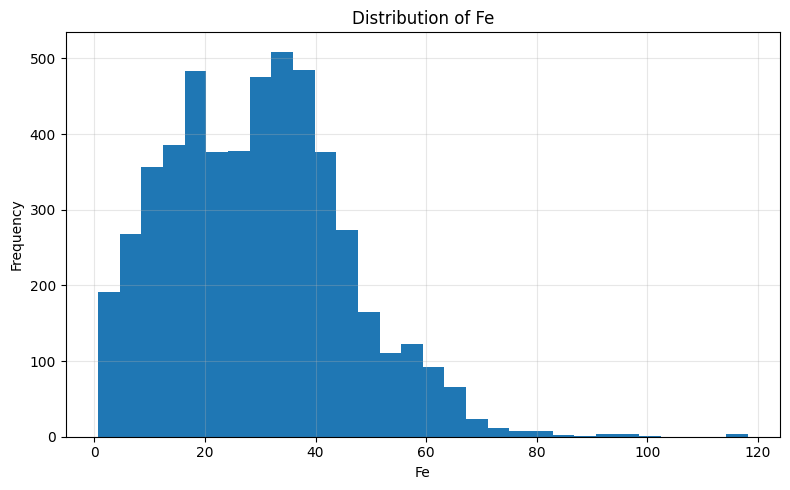

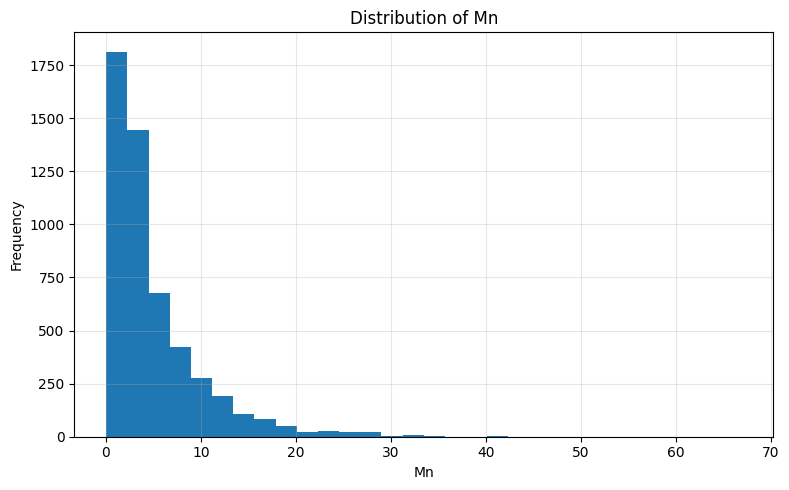

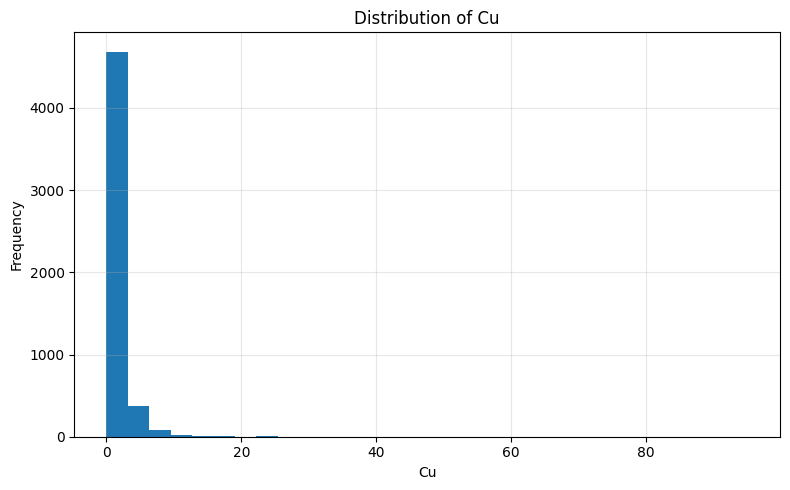

In [64]:
import matplotlib.pyplot as plt

for col in soil_cols:

    plt.figure(figsize=(8,5))

    plt.hist(df4[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [65]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers, lower, upper


for col in soil_cols:

    outliers, lower, upper = detect_outliers(df4, col)

    print(
        col,
        "Outliers:", len(outliers),
        "Lower:", lower,
        "Upper:", upper
    )

PH Outliers: 88 Lower: 3.719999999999999 Upper: 6.280000000000001
EC Outliers: 657 Lower: -0.10999999999999999 Upper: 0.37
OC Outliers: 3 Lower: -0.6075070820000001 Upper: 3.51917847
N Outliers: 2 Lower: -58.030604250000025 Upper: 340.72180279
P Outliers: 208 Lower: -85.06196999999999 Upper: 163.41955
K Outliers: 244 Lower: -225.39167500000002 Upper: 773.316525
S Outliers: 542 Lower: -12.823519500000003 Upper: 30.491479700000003
Zn Outliers: 475 Lower: -0.9857500000000005 Upper: 3.5282500000000008
B Outliers: 248 Lower: -0.349068 Upper: 0.82674
Fe Outliers: 33 Lower: -16.734999999999996 Upper: 73.529
Mn Outliers: 323 Lower: -5.47475 Upper: 13.71125
Cu Outliers: 342 Lower: -1.6367500000000001 Upper: 3.86925


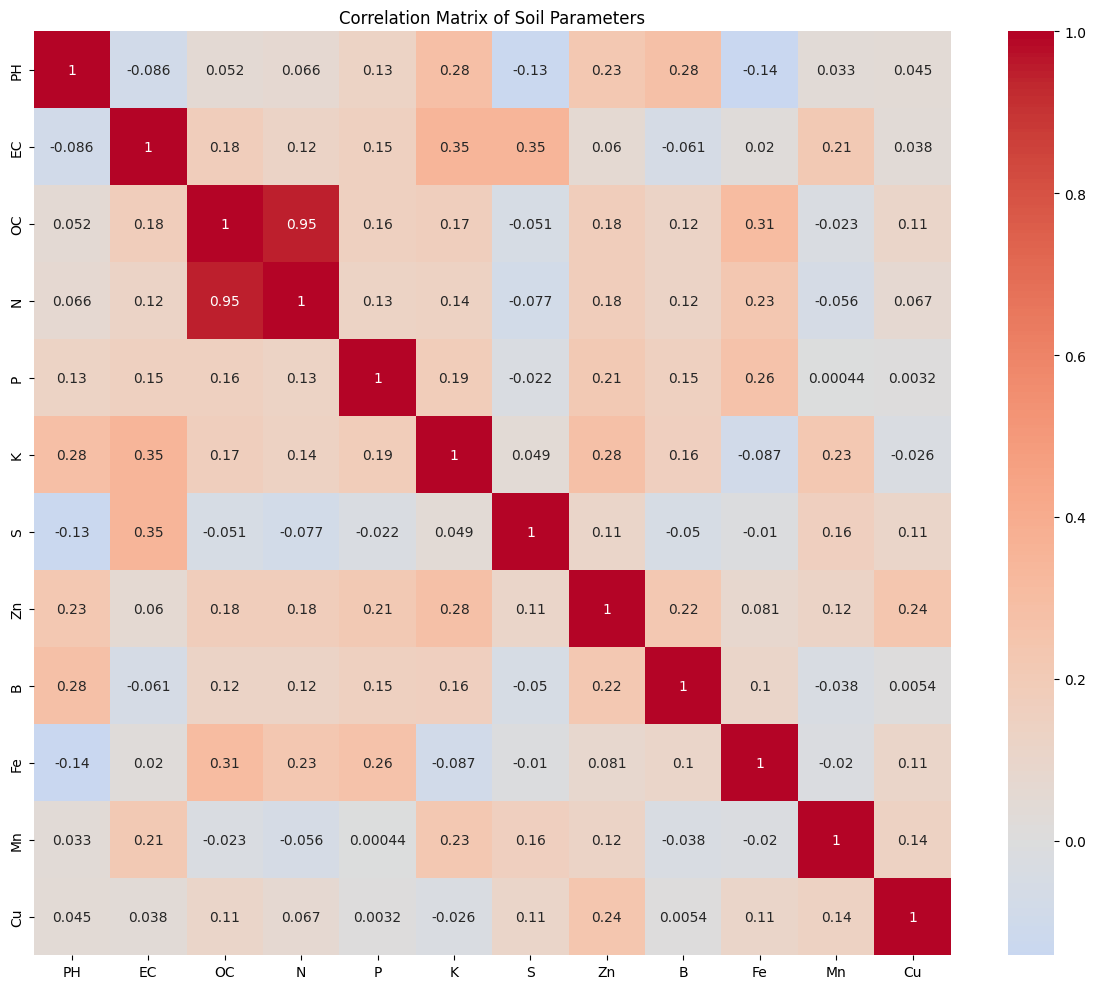

In [67]:
import seaborn as sns

corr = df4[soil_cols].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Soil Parameters")

plt.tight_layout()
plt.show()

2024-25_Soil_Test_Results_Samples.csv

In [68]:
df5 = pd.read_csv("/content/2024-25_Soil_Test_Results_Samples.csv")

print("Shape:", df5.shape)

print("\nColumns:")
print(df5.columns)

print("\nData Types:")
print(df5.dtypes)

print("\nFirst 5 rows:")
print(df5.head())

Shape: (5342, 14)

Columns:
Index(['Sl. No.', 'Place', 'pH', 'EC       ds/m', 'OC            %',
       'N          kg/hectre', 'P          kg/hectre', 'K        kg/hectre',
       'S         ppm', 'Zn                ppm    ', 'B          ppm',
       'Fe        ppm', 'Mn      ppm', 'Cu        ppm'],
      dtype='object')

Data Types:
Sl. No.                      float64
Place                         object
pH                           float64
EC       ds/m                float64
OC            %              float64
N          kg/hectre         float64
P          kg/hectre         float64
K        kg/hectre           float64
S         ppm                float64
Zn                ppm        float64
B          ppm               float64
Fe        ppm                float64
Mn      ppm                  float64
Cu        ppm                float64
dtype: object

First 5 rows:
   Sl. No.   Place    pH  EC       ds/m  OC            %  \
0      1.0  Uppoor  4.21           0.50         1.633663

In [69]:
import re
STD_MAP = {
    'ph': 'PH', 'ec': 'EC', 'oc': 'OC', 'n': 'N', 'p': 'P', 'k': 'K', 's': 'S',
    'zn': 'Zn', 'b': 'B', 'fe': 'Fe', 'mn': 'Mn', 'cu': 'Cu',
}

def standardize_column(col):
    """'EC       ds/m' -> 'EC' ; 'N          kg/hectre' -> 'N' ; 'PH' -> 'pH' """
    cleaned = re.sub(r"\s+", " ", str(col)).strip()   # collapse multiple spaces into one
    first_word = cleaned.split(" ")[0].lower()
    return STD_MAP.get(first_word, cleaned)

In [70]:
df5.columns = [standardize_column(c) for c in df5.columns]

In [71]:
df5.head()

,Sl. No.,Place,PH,EC,OC,N,P,K,S,Zn,B,Fe,Mn,Cu
0,1.0,Uppoor,4.21,0.50,1.633663,365.940594,9.568,292.096,74.091446,2.050,0.293952,41.86,6.378,2.664
1,2.0,Uppoor,5.00,0.14,1.217822,272.792079,87.906,76.272,28.496710,0.560,0.514416,49.22,2.696,0.298
2,3.0,Uppoor,4.90,0.18,1.277228,286.099010,24.518,83.328,15.958158,0.490,0.716508,28.70,4.388,1.634
3,4.0,Uppoor,4.45,0.50,1.722772,385.900990,9.867,185.360,16.528092,0.594,0.257208,33.64,9.314,2.020
4,5.0,Uppoor,4.83,0.13,1.722772,385.900990,84.019,91.056,21.657500,3.052,0.587904,28.56,5.034,0.838


In [72]:
df5 = df5.drop(columns=["Sl. No.","Place"])
df5.head()

,PH,EC,OC,N,P,K,S,Zn,B,Fe,Mn,Cu
0,4.21,0.50,1.633663,365.940594,9.568,292.096,74.091446,2.050,0.293952,41.86,6.378,2.664
1,5.00,0.14,1.217822,272.792079,87.906,76.272,28.496710,0.560,0.514416,49.22,2.696,0.298
2,4.90,0.18,1.277228,286.099010,24.518,83.328,15.958158,0.490,0.716508,28.70,4.388,1.634
3,4.45,0.50,1.722772,385.900990,9.867,185.360,16.528092,0.594,0.257208,33.64,9.314,2.020
4,4.83,0.13,1.722772,385.900990,84.019,91.056,21.657500,3.052,0.587904,28.56,5.034,0.838


In [73]:
missing = df4.isnull().sum()
print(missing)

missing_percent = df4.isnull().mean() * 100
print(missing_percent)


PH    0
EC    0
OC    0
N     0
P     0
K     0
S     0
Zn    0
B     0
Fe    0
Mn    0
Cu    0
dtype: int64
PH    0.0
EC    0.0
OC    0.0
N     0.0
P     0.0
K     0.0
S     0.0
Zn    0.0
B     0.0
Fe    0.0
Mn    0.0
Cu    0.0
dtype: float64


In [74]:
summary = pd.DataFrame({
    "Mean": df5[soil_cols].mean(),
    "Median": df5[soil_cols].median(),
    "Std": df5[soil_cols].std(),
    "Min": df5[soil_cols].min(),
    "Max": df5[soil_cols].max()
})

print(summary)

          Mean      Median         Std        Min          Max
PH    5.037318    4.950000    0.525440   3.220000     9.680000
EC    0.109972    0.070000    0.150805   0.010000     1.990000
OC    1.287155    1.171429    0.706265   0.028571     5.428571
N   285.312763  258.461539  159.940730  14.769231  1216.000000
P    71.846493   47.541000   71.111566   0.598000   490.911459
K   201.986447  159.376000  152.068952  21.242000  1070.272000
S    14.977564    8.549013   30.647141   0.032487   454.807492
Zn    1.093097    0.774000    1.167969   0.002000    14.330000
B     0.476927    0.385812    0.460017   0.018372    10.839480
Fe   29.433527   29.400000   14.920532   0.942000   116.940000
Mn    3.460870    2.086000    3.625118   0.008000    30.140000
Cu    1.003992    0.740000    1.158477   0.010000    15.132000


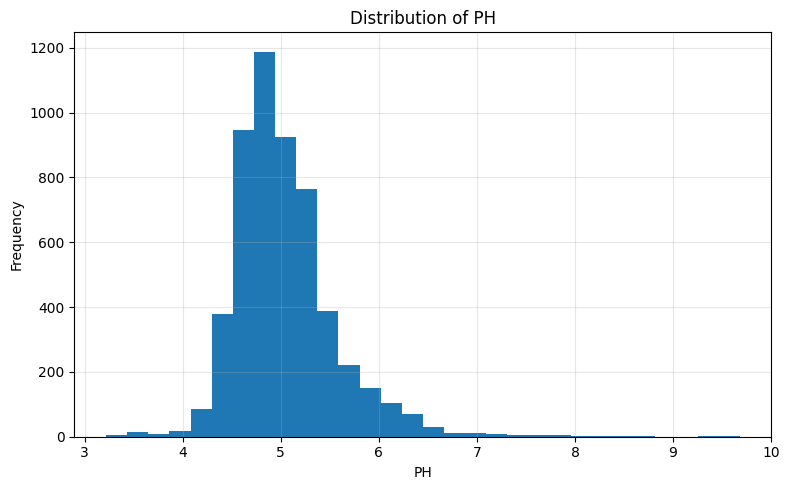

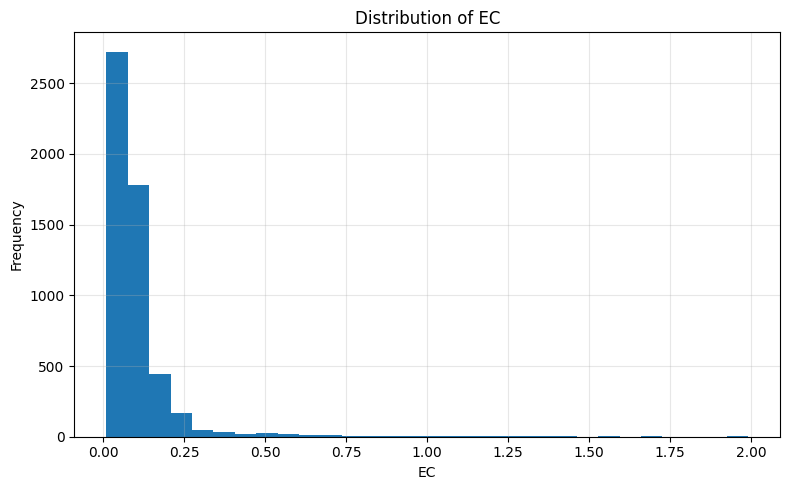

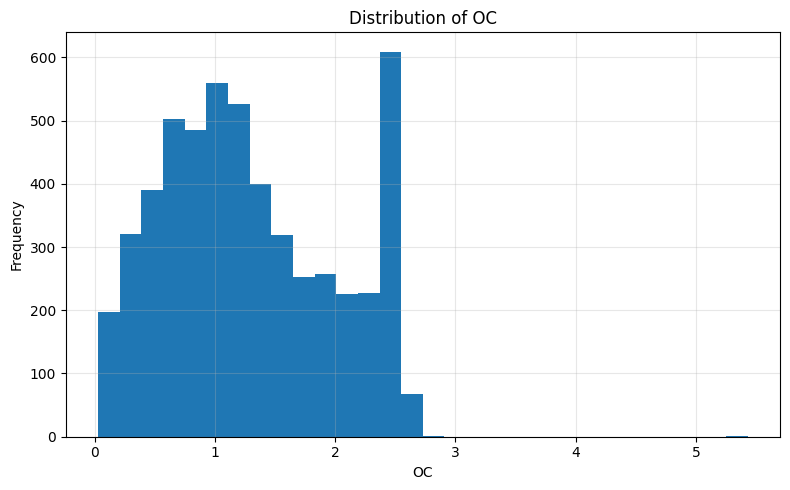

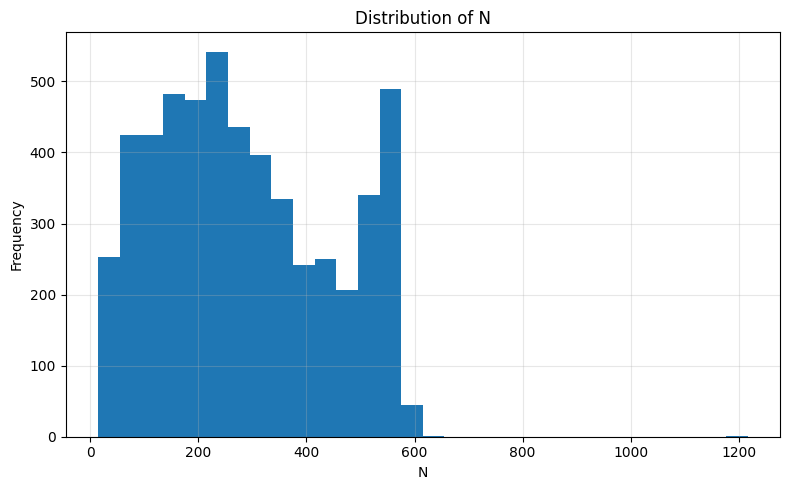

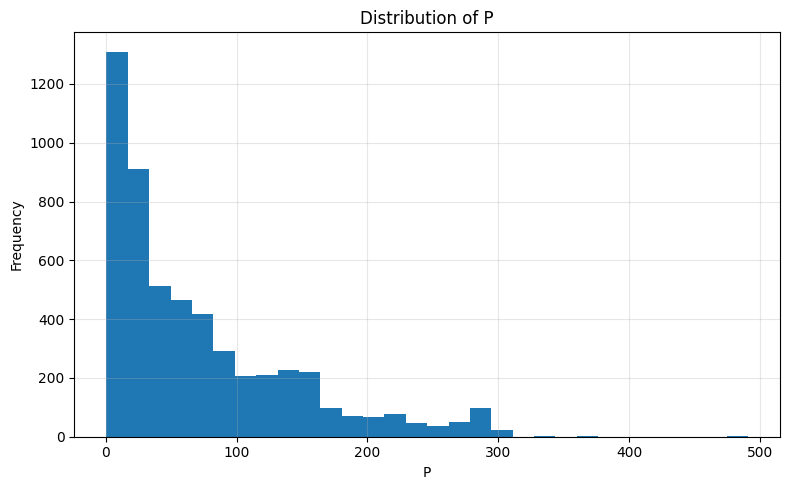

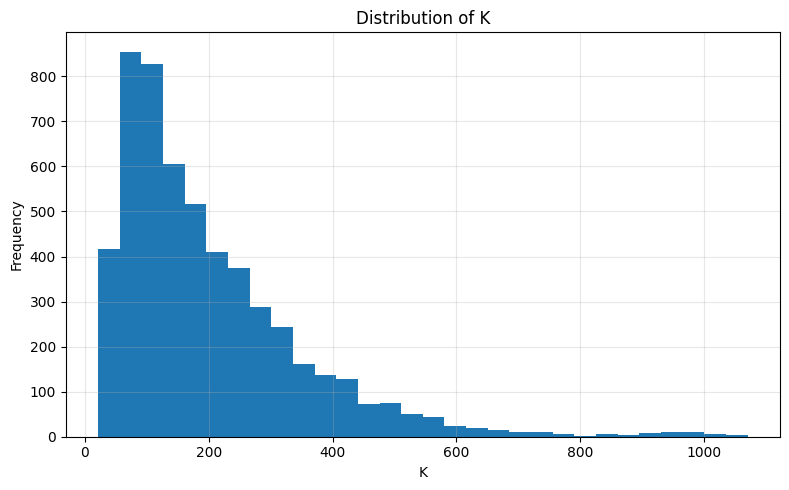

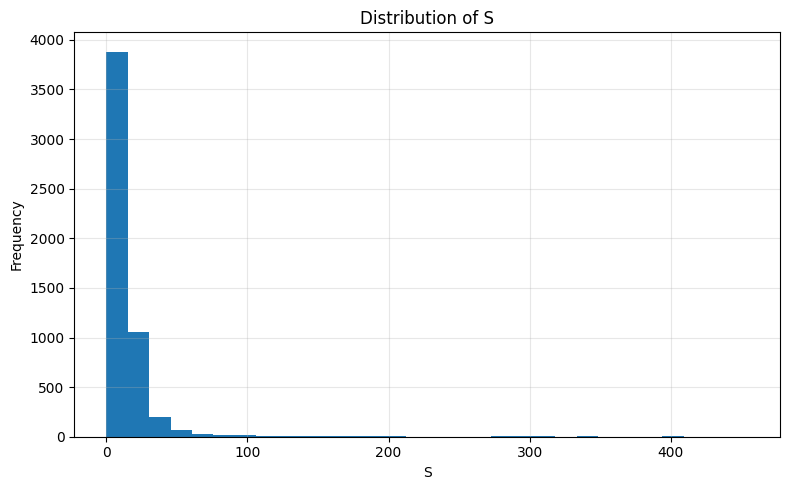

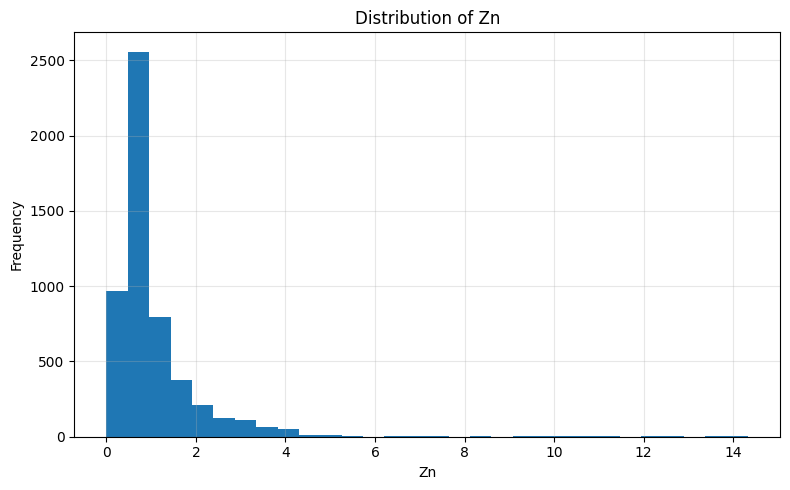

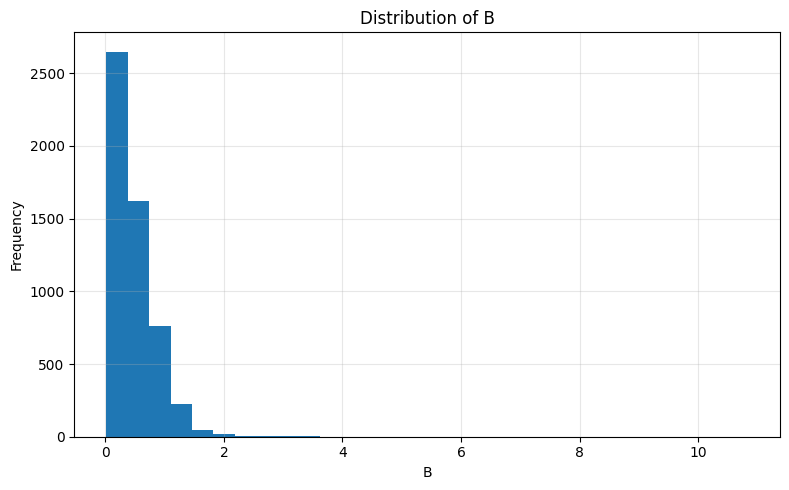

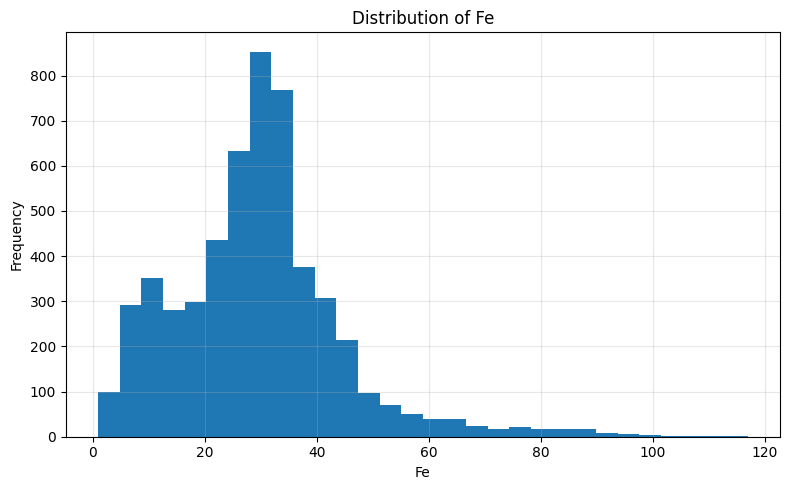

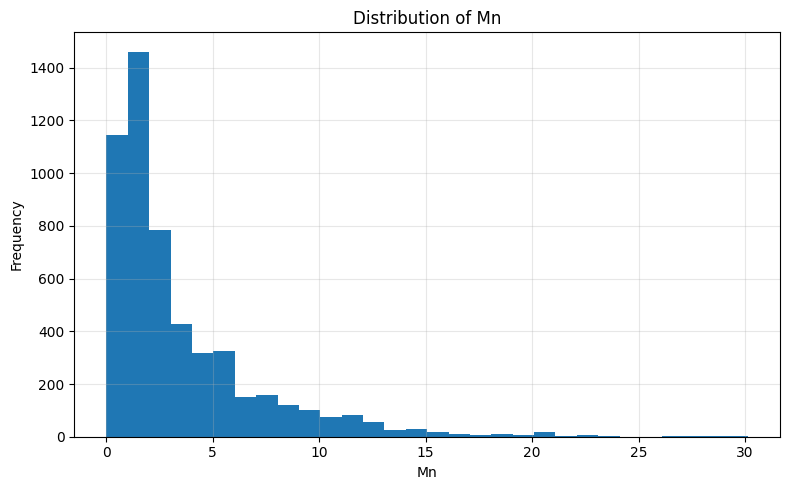

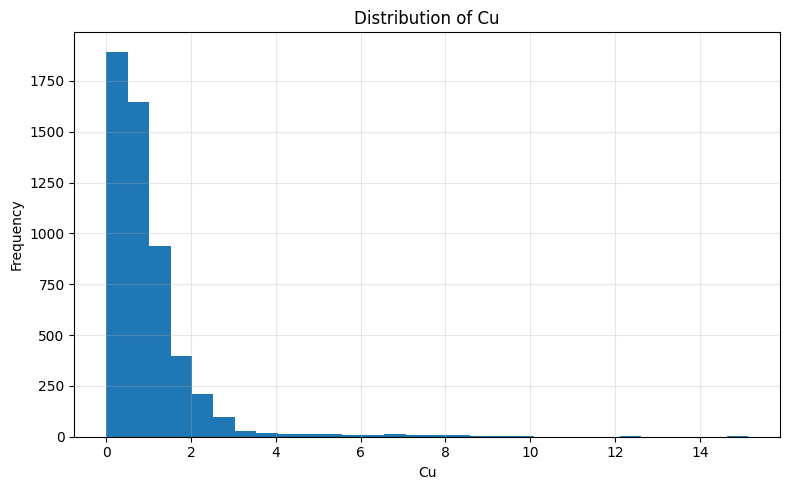

In [75]:
import matplotlib.pyplot as plt

for col in soil_cols:

    plt.figure(figsize=(8,5))

    plt.hist(df5[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [76]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers, lower, upper


for col in soil_cols:

    outliers, lower, upper = detect_outliers(df5, col)

    print(
        col,
        "Outliers:", len(outliers),
        "Lower:", lower,
        "Upper:", upper
    )

PH Outliers: 226 Lower: 3.845000000000001 Upper: 6.124999999999998
EC Outliers: 337 Lower: -0.05499999999999998 Upper: 0.22499999999999998
OC Outliers: 1 Lower: -0.9725274729999998 Upper: 3.5549450549999997
N Outliers: 1 Lower: -235.02159306249993 Upper: 803.2624636374999
P Outliers: 233 Lower: -115.414 Upper: 238.602
K Outliers: 203 Lower: -165.018 Upper: 525.014
S Outliers: 334 Lower: -13.963387899999999 Upper: 33.9110849
Zn Outliers: 531 Lower: -0.3922499999999999 Upper: 2.10975
B Outliers: 112 Lower: -0.5327879999999999 Upper: 1.3779
Fe Outliers: 217 Lower: -2.520000000000003 Upper: 58.6
Mn Outliers: 370 Lower: -4.067 Upper: 9.809000000000001
Cu Outliers: 254 Lower: -0.9349999999999999 Upper: 2.545


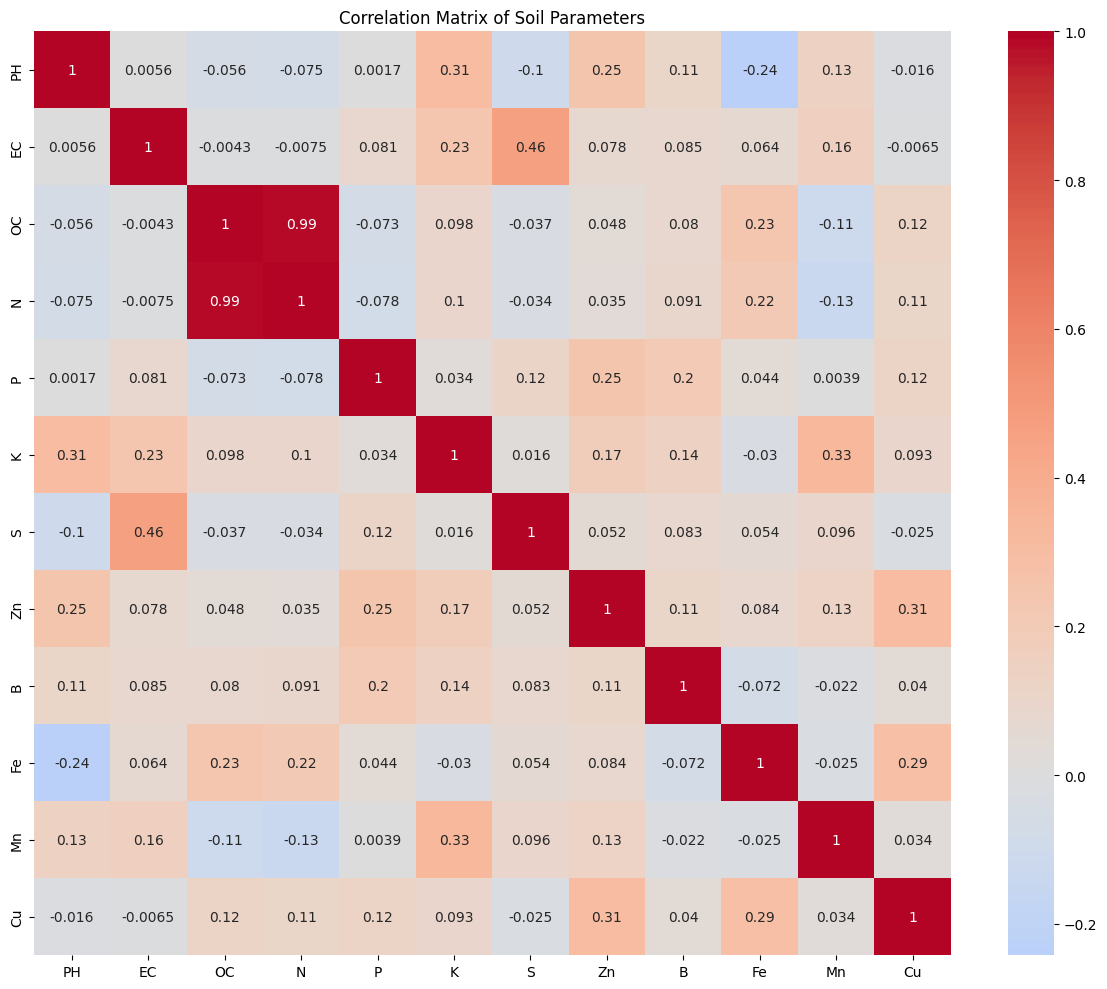

In [77]:
import seaborn as sns

corr = df5[soil_cols].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Soil Parameters")

plt.tight_layout()
plt.show()